# Reassessing U.S. Heatwave Trends with Bias-Corrected Observations

Analysis code for every figure in the paper.

**How the notebook is laid out.** The first four sections build the machinery the
figures share: where the data are, the CONUS polygon, the anomaly-first pipeline, and
the gridded loaders. Each is followed by a `CHECK` cell that tests what was just
defined, so a failure is located before any figure is drawn. Most checks run on
synthetic numbers and need no data at all. The six figure sections then follow, each
split into *settings and helpers*, *build*, *check*, and *plot*.

**How to run it.** Run Setup first, then the sections in order, or run Setup plus the
shared sections and jump to the figure you want. Within a figure, run its cells in
order: the build cell leaves its series in memory for the check and plot cells.

**First run is slow.** Each loader reads the raw archives once and caches what it
builds under `_cache_*/`; later runs read the cache in seconds. The figures write to
`PAPER_FIGURES_FINAL/`.

| Section | Figure | What it shows |
| --- | --- | --- |
| 5 | Figure 1 | CONUS JJA anomalies, TMAX / TMIN / TAVG, eight datasets |
| 6 | Figure 2 | Seasonal bars, DJF-SON by TMAX / TMIN / TAVG, Dust Bowl vs. modern |
| 7 | Figure 3 | CONUS daily TMAX record frequency, May-September |
| 8 | Figure 4 | Berkeley Earth exceedance maps, p95 from the full record |
| 9 | Figure 5 | Northern mid-latitude band, 24-50N, JJA |
| 10 | Figure 6 | Heat-wave days, CONUS vs. the global strip, Christy (2026) method |

Figures 1 and 2 previously carried identical copies of the whole pipeline; the copies
were compared statement by statement and merged into section 3. Nothing else about the
computation changed.


## 1. Setup

Paths, imports, and the settings every figure shares. Run this first.


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# SETUP -- imports, data locations, and the settings every figure shares.
# Run this cell first; everything below depends on it.
# ══════════════════════════════════════════════════════════════════════════════
import os, re, calendar, warnings, pickle
from pathlib import Path
from functools import lru_cache

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
from matplotlib.transforms import blended_transform_factory
from matplotlib.colors import TwoSlopeNorm
from scipy.spatial import cKDTree
import cartopy.crs as ccrs
import cartopy.feature as cfeature

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ── where the data live ──────────────────────────────────────────────────────
ROOT = Path("/Volumes/Expansion/homogenized_dataset_analysis")   # raw archives
WORK = Path("/Users/jessesmac/Myprojects/PHD_work/homogenized_dataset_work")
FIGD = WORK / "PAPER_FIGURES_FINAL"

GHCND_GLOBAL = ROOT / "GHCND" / "Global"          # ghcn_global_YYYY.parquet
GHCND_INV    = ROOT / "GHCND" / "ghcnd-inventory.txt"
BE_PROC      = ROOT / "Berkeley_Earth" / "Processed"
BE_RAW       = ROOT / "Berkeley_Earth" / "RAW"
BE_TMAX      = BE_PROC / "preprocessed_us_TMAX_data.nc"
BE_TMIN      = BE_PROC / "preprocessed_us_TMIN_data.nc"
BE_TAVG      = BE_PROC / "preprocessed_us_TAVG_data.nc"
ERA5_DIR     = ROOT / "ERA5"
NOAA_FP      = (ROOT / "noaaglobaltemp" /
                "NOAAGlobalTemp_v6.0.0_gridded_s185001_e202512_c20260107T093746.nc")
CRUTEM_FP    = ROOT / "crutem5" / "CRUTEM.5.1.0.0.anomalies.nc"
NCLIMDIV_DIR = ROOT / "nclimdiv"
USREG_FP     = Path("/Volumes/Expansion/christy2026/usreg_half.txt")

UH_PAIRED    = WORK / "_cache_ushcn_homog" / "ushcn_homog_station_months_paired.parquet"
UH_PIV_DIR   = WORK / "_cache_ushcn_homog"
UH_WORKDIR   = ROOT / "ushcn_daily_homog"
UH_STN_FP    = UH_WORKDIR / "output" / "stations.csv"
UH_DAILY_DIR = UH_WORKDIR / "output" / "daily"

# ── caches (built on first run, reused afterwards) ───────────────────────────
CACHE_ANOM  = WORK / "_cache_fig1_adessler"     # Figures 1 and 2
CACHE_REC   = FIGD / "cache_fixed_metrics"      # Figure 3, and the cube Figure 6 reads
CACHE_MAPS  = CACHE_REC / "global"              # Figure 4
CACHE_BAND  = WORK / "_cache_band_jja"          # Figure 5
CACHE_HW    = WORK / "_cache_christy_hw"        # Figure 6
for _d in (FIGD, CACHE_ANOM, CACHE_REC, CACHE_MAPS, CACHE_BAND, CACHE_HW):
    _d.mkdir(parents=True, exist_ok=True)

# ── settings Figures 1 and 2 share ───────────────────────────────────────────
BASELINE  = (1951, 1980)          # anomaly baseline, both figures
BOX       = dict(lat_min=24.0, lat_max=50.0, lon_min=-125.0, lon_max=-66.0)
MIN_BASE_STN  = 15        # of 30 baseline years, per station per calendar month
MIN_BASE_CELL = 20        # of 30, per grid cell per calendar month
MIN_DAYS_FRAC = 0.80      # station-month completeness
MIN_DAYS_MON  = 20        # days needed for a monthly mean of a gridded daily field
EARTH_R = 6371.0088
G05_LAT_EDGES = np.round(np.arange(25.0, 50.0 + 1e-9, 0.5), 3)   # 0.5 deg CONUS grid
G05_LON_EDGES = np.round(np.arange(-124.5, -66.5 + 1e-9, 0.5), 3)


In [13]:
# CHECK -- can this machine see the data? Everything below needs the archive
# drive mounted; the caches are created above if they do not exist.
_paths = {"GHCN-Daily parquets": GHCND_GLOBAL, "GHCN-Daily inventory": GHCND_INV,
          "Berkeley (CONUS daily)": BE_TMAX, "Berkeley (NH decades)": BE_PROC,
          "Berkeley RAW": BE_RAW, "ERA5": ERA5_DIR, "NOAAGlobalTemp": NOAA_FP,
          "CRUTEM5": CRUTEM_FP, "nCLIMDIV": NCLIMDIV_DIR,
          "USHCN paired months": UH_PAIRED, "USHCN daily output": UH_DAILY_DIR,
          "Christy usreg mask": USREG_FP}
print(f"{'dataset':<26}{'status':<9}path")
for _name, _p in _paths.items():
    print(f"  {_name:<24}{'OK' if _p.exists() else 'MISSING':<9}{_p}")
_missing = [n for n, p in _paths.items() if not p.exists()]
print("\nall present" if not _missing else
      f"\nmissing: {', '.join(_missing)} -- the figures that need them cannot run")


dataset                   status   path
  GHCN-Daily parquets     OK       /Volumes/Expansion/homogenized_dataset_analysis/GHCND/Global
  GHCN-Daily inventory    OK       /Volumes/Expansion/homogenized_dataset_analysis/GHCND/ghcnd-inventory.txt
  Berkeley (CONUS daily)  OK       /Volumes/Expansion/homogenized_dataset_analysis/Berkeley_Earth/Processed/preprocessed_us_TMAX_data.nc
  Berkeley (NH decades)   OK       /Volumes/Expansion/homogenized_dataset_analysis/Berkeley_Earth/Processed
  Berkeley RAW            OK       /Volumes/Expansion/homogenized_dataset_analysis/Berkeley_Earth/RAW
  ERA5                    OK       /Volumes/Expansion/homogenized_dataset_analysis/ERA5
  NOAAGlobalTemp          OK       /Volumes/Expansion/homogenized_dataset_analysis/noaaglobaltemp/NOAAGlobalTemp_v6.0.0_gridded_s185001_e202512_c20260107T093746.nc
  CRUTEM5                 OK       /Volumes/Expansion/homogenized_dataset_analysis/crutem5/CRUTEM.5.1.0.0.anomalies.nc
  nCLIMDIV                OK       /V

## 2. Geometry

One CONUS polygon, used by every figure: as fractional area weights for the gridded averages, and as a point-in-polygon test for the station and heat-wave figures.


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# GEOMETRY -- one CONUS polygon for every figure.
#
# Natural Earth 50m United States, clipped to 24-50N / 125-66W, minus lakes.
# Figures 1-3 and 5-6 all used to carry their own copy of this; the copies were
# identical, so there is one here. Two ways of using it are provided: a
# FRACTIONAL AREA WEIGHT per cell (what the anomaly figures average with) and a
# POINT-IN-POLYGON test (what the station and heat-wave figures mask with).
# ══════════════════════════════════════════════════════════════════════════════
def conus_polygon():
    import geopandas as gpd
    from cartopy.io import shapereader
    from shapely.geometry import box as sbox
    from shapely.ops import unary_union
    b = sbox(BOX["lon_min"], BOX["lat_min"], BOX["lon_max"], BOX["lat_max"])
    c = gpd.read_file(shapereader.natural_earth("50m","cultural","admin_0_countries"))
    col = "ADMIN" if "ADMIN" in c.columns else "NAME"
    usa = c[c[col] == "United States of America"]
    parts = [g for g in usa.geometry.explode(index_parts=False) if g.intersects(b)]
    poly = unary_union(parts).intersection(b)
    lakes = gpd.read_file(shapereader.natural_earth("50m","physical","lakes"))
    return poly.difference(unary_union([g for g in lakes.geometry if g.intersects(b)]))

@lru_cache(maxsize=1)
def land_polygon():
    """Natural Earth 50m land. Figure 6's global strip is masked with this, so
    that ocean persistence is not counted as heat waves."""
    import geopandas as gpd
    from cartopy.io import shapereader
    from shapely.ops import unary_union
    land = gpd.read_file(shapereader.natural_earth("50m", "physical", "land"))
    return unary_union(list(land.geometry))


def _edges(c):
    c = np.asarray(c, float); d = np.diff(c)
    return np.concatenate([[c[0]-d[0]/2], c[:-1]+d/2, [c[-1]+d[-1]/2]])

def cell_weights(lat_c, lon_c, key=None):
    if key is not None and (CACHE_ANOM / f"weights_{key}.nc").exists():
        return xr.load_dataarray(CACHE_ANOM / f"weights_{key}.nc")
    import shapely
    from shapely.geometry import box as sbox
    poly = conus_polygon()
    la, lo = _edges(lat_c), _edges(lon_c)
    frac = np.zeros((len(lat_c), len(lon_c)))
    cells, idx = [], []
    for i in range(len(lat_c)):
        for j in range(len(lon_c)):
            cells.append(sbox(lo[j], la[i], lo[j+1], la[i+1])); idx.append((i,j))
    tree = shapely.STRtree(np.array(cells, dtype=object))
    for h in np.atleast_1d(tree.query(poly, predicate="intersects")):
        i, j = idx[h]; c = cells[h]
        frac[i, j] = poly.intersection(c).area / c.area if c.area > 0 else 0.0
    band = np.abs(np.sin(np.radians(la[1:])) - np.sin(np.radians(la[:-1])))[:, None]
    w = xr.DataArray(frac*band, dims=("lat","lon"), coords={"lat":lat_c,"lon":lon_c})
    if key is not None:
        w.name = f"weights_{key}"; w.to_netcdf(CACHE_ANOM / f"weights_{key}.nc")
    return w

def g05_centers():
    return (0.5*(G05_LAT_EDGES[:-1]+G05_LAT_EDGES[1:]),
            0.5*(G05_LON_EDGES[:-1]+G05_LON_EDGES[1:]))

def points_inside(lat, lon):
    poly = conus_polygon()
    try:
        import shapely
        return np.asarray(shapely.contains_xy(poly, np.asarray(lon), np.asarray(lat)))
    except Exception:                                   # shapely 1.x
        from shapely.geometry import Point
        from shapely.prepared import prep
        pp = prep(poly)
        return np.array([pp.contains(Point(o, a)) for a, o in zip(lat, lon)])

def points_in_grid(geom, lat, lon):
    lon = np.where(np.asarray(lon) > 180.0, np.asarray(lon) - 360.0, np.asarray(lon))
    LON, LAT = np.meshgrid(lon, np.asarray(lat))
    try:
        import shapely
        m = np.asarray(shapely.contains_xy(geom, LON.ravel(), LAT.ravel()))
    except Exception:
        from shapely.geometry import Point
        from shapely.prepared import prep
        pp = prep(geom)
        m = np.array([pp.contains(Point(o, a))
                      for a, o in zip(LAT.ravel(), LON.ravel())])
    return m.reshape(LAT.shape)


In [15]:
# CHECK -- the polygon and the weights, without touching the data drive.
_poly = conus_polygon()
_inside  = [(-98.5, 39.0, "Kansas"), (-84.4, 33.7, "Georgia"), (-119.0, 36.5, "California")]
_outside = [(-103.0, 25.0, "northern Mexico"), (-113.5, 51.0, "Alberta"),
            (-87.5, 44.0, "Lake Michigan"), (-70.0, 41.0, "Atlantic")]
for _lon, _lat, _nm in _inside:
    assert points_inside([_lat], [_lon])[0], f"{_nm} should be inside CONUS"
for _lon, _lat, _nm in _outside:
    assert not points_inside([_lat], [_lon])[0], f"{_nm} should be outside CONUS"
print(f"point-in-polygon: {len(_inside)} inside / {len(_outside)} outside all correct")

_lat05, _lon05 = g05_centers()
_W05 = cell_weights(_lat05, _lon05, key="g05")
assert float(_W05.min()) >= 0 and float(_W05.sum()) > 0
print(f"0.5 deg grid: {_W05.shape[0]}x{_W05.shape[1]} cells, "
      f"{int((_W05 > 0).sum()):,} with weight, "
      f"weights sum to {float(_W05.sum()):.4f} of a hemisphere-band unit")
print(f"widest-weighted cell: lat {float(_W05.idxmax(dim='lat').max()):.2f} "
      f"(band area falls off with latitude, as it should)")


point-in-polygon: 3 inside / 4 outside all correct
0.5 deg grid: 50x116 cells, 3,523 with weight, weights sum to 21.8787 of a hemisphere-band unit
widest-weighted cell: lat 45.25 (band area falls off with latitude, as it should)


## 3. The anomaly-first pipeline

Station anomalies, IDW gridding, cell anomalies, area averaging and day-weighted seasonal means. Figures 1 and 2 share all of it.


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# THE ANOMALY-FIRST PIPELINE (Figures 1 and 2)
#
# Every station is converted to an anomaly against ITS OWN 1951-1980 monthly
# climatology BEFORE gridding, and every grid cell against its own before the
# cells are averaged. Averaging absolute temperatures first lets a change in
# which stations report move the series, because stations differ in elevation
# and exposure.
#
# Figures 1 and 2 ran identical copies of everything in this cell; the copies
# were compared statement by statement before being merged. The only change is
# that the year axis is now an argument (`years`) instead of a global, because
# Figure 1 runs 1900-2024 and Figure 2 needs 1900-2025 for its DJF bar.
# ══════════════════════════════════════════════════════════════════════════════

def _cache(key, build):
    fp = CACHE_ANOM / f"{key}.nc"
    if fp.exists():
        return xr.load_dataarray(fp)
    da = build(); da.name = key; da.to_netcdf(fp); return da

# ══ THE COMMON TAIL ═════════════════════════════════════════════════════════
def cell_anomalies(da, min_base=MIN_BASE_CELL):
    w = da.sel(time=slice(f"{BASELINE[0]}-01-01", f"{BASELINE[1]}-12-31"))
    clim = w.groupby("time.month").mean("time", skipna=True)
    clim = clim.where(w.groupby("time.month").count("time") >= min_base)
    return (da.groupby("time.month") - clim).drop_vars("month", errors="ignore")

def area_mean(da, weights):
    w = weights.where(da.notnull(), 0.0)
    den = w.sum(("lat","lon")); num = (da.fillna(0.0)*w).sum(("lat","lon"))
    return num/den.where(den > 0), den/float(weights.sum())

def _to_year_month(s, years):
    out = np.full((len(years), 12), np.nan)
    t = pd.DatetimeIndex(s["time"].values)
    yi = pd.Index(years).get_indexer(t.year); ok = yi >= 0
    out[yi[ok], t.month.to_numpy()[ok]-1] = np.asarray(s.values, float)[ok]
    return out

def _season_offsets(months):
    """Year offset of each month relative to the season's label year: a season
    is labelled by the year of its LAST month, so DJF is (-1,0,0)."""
    off = [0]; rev = list(months)[::-1]
    for p, c in zip(rev[:-1], rev[1:]):
        off.append(off[-1] - (1 if c > p else 0))
    return list(reversed(off))

def season_mean(monthly, months, years):
    """day-weighted seasonal mean; NaN unless every month of the season is there."""
    n = len(years)
    lengths = np.array([[calendar.monthrange(int(y), m)[1] for m in range(1,13)]
                        for y in years])
    tot = np.zeros(n); wt = np.zeros(n); complete = np.ones(n, bool)
    for m, off in zip(months, _season_offsets(months)):
        src = np.arange(n) + off; inside = (src >= 0) & (src < n)
        idx = np.clip(src, 0, n-1)
        vals = np.where(inside, monthly[idx, m-1], np.nan)
        w = np.where(inside, lengths[idx, m-1], 0)
        complete &= np.isfinite(vals)
        tot += np.where(np.isfinite(vals), vals*w, 0.0)
        wt  += np.where(np.isfinite(vals), w, 0)
    with np.errstate(invalid="ignore"):
        out = tot/np.where(wt > 0, wt, np.nan)
    return np.where(complete, out, np.nan)

# ══ STATIONS: anomaly-first, then IDW ═══════════════════════════════════════
def _xyz(lat, lon):
    la = np.radians(np.asarray(lat, float)); lo = np.radians(np.asarray(lon, float))
    return np.column_stack([np.cos(la)*np.cos(lo), np.cos(la)*np.sin(lo), np.sin(la)])

class IDWGrid:
    def __init__(self, lat_c, lon_c, power=2.0, k=8, radius_km=150.0):
        self.lat = np.asarray(lat_c, float); self.lon = np.asarray(lon_c, float)
        self.power, self.k, self.radius = power, k, radius_km
        LON, LAT = np.meshgrid(self.lon, self.lat)
        self.shape = LAT.shape; self.cells = _xyz(LAT.ravel(), LON.ravel())
    def grid(self, values, slat, slon):
        v = np.asarray(values, float); ok = np.isfinite(v)
        if not ok.any(): return np.full(self.shape, np.nan)
        tree = cKDTree(_xyz(np.asarray(slat)[ok], np.asarray(slon)[ok]))
        k = min(self.k, int(ok.sum()))
        chord = 2.0*np.sin(0.5*self.radius/EARTH_R)
        dist, idx = tree.query(self.cells, k=k, distance_upper_bound=chord)
        if k == 1: dist = dist[:, None]; idx = idx[:, None]
        good = np.isfinite(dist); idxs = np.where(good, idx, 0)
        arc = 2.0*EARTH_R*np.arcsin(np.clip(dist/2.0, 0, 1))
        with np.errstate(divide="ignore", invalid="ignore"):
            w = np.where(good, np.power(np.maximum(arc, 1e-6), -self.power), 0.0)
        exact = good & (arc < 1e-3); rows = exact.any(axis=1)
        w[rows] = np.where(exact[rows], 1.0, 0.0)
        ws = w.sum(1); vv = v[ok]
        out = np.where(ws > 0, (w*vv[idxs]).sum(1)/np.where(ws > 0, ws, 1.0), np.nan)
        return out.reshape(self.shape)

def station_anomalies(sm, min_base=MIN_BASE_STN):
    b = sm[sm["year"].between(*BASELINE)]
    g = b.groupby(["id","month"])["v"].agg(["mean","count"])
    clim = g[g["count"] >= min_base]["mean"].rename("clim")
    out = sm.join(clim, on=["id","month"]).dropna(subset=["clim"]).copy()
    out["v"] = out["v"] - out["clim"]
    return out.drop(columns="clim")

def grid_station_field(sm, gridder, years):
    piv = sm.pivot_table(index="id", columns=["year","month"], values="v")
    meta = sm.groupby("id")[["lat","lon"]].first().reindex(piv.index)
    slat, slon = meta["lat"].values, meta["lon"].values
    nt = len(years)*12
    field = np.full((nt, *gridder.shape), np.nan, np.float32)
    t = 0
    for y in years:
        for m in range(1, 13):
            if (y, m) in piv.columns:
                field[t] = gridder.grid(piv[(y, m)].values, slat, slon)
            t += 1
    time = pd.date_range(f"{years[0]}-01-01", periods=nt, freq="MS")
    return xr.DataArray(field, dims=("time","lat","lon"),
                        coords=dict(time=time, lat=gridder.lat, lon=gridder.lon))

def ghcnd_station_months(years):
    """One pass over the yearly GHCN-Daily parquets -> CONUS station-months.
    Shared with the v11 cell's cache."""
    fp = CACHE_ANOM / "ghcnd_conus_station_months.parquet"
    if fp.exists():
        return pd.read_parquet(fp)
    parts = []
    for y in range(years[0], years[-1]+1):
        f = GHCND_GLOBAL / f"ghcn_global_{y}.parquet"
        if not f.exists(): continue
        d = pd.read_parquet(f, columns=["station_id","date","tmax_c","tmin_c","lat","lon"])
        d = d[(d.lat.between(BOX["lat_min"], BOX["lat_max"])) &
              (d.lon.between(BOX["lon_min"], BOX["lon_max"]))]
        if d.empty: continue
        d = d.assign(year=d.date.dt.year, month=d.date.dt.month)
        d["tavg_c"] = np.where(d.tmax_c.notna() & d.tmin_c.notna(),
                               (d.tmax_c+d.tmin_c)/2, np.nan)
        parts.append(d.groupby(["station_id","year","month"]).agg(
            tmax_s=("tmax_c","sum"), tmax_n=("tmax_c","count"),
            tmin_s=("tmin_c","sum"), tmin_n=("tmin_c","count"),
            tavg_s=("tavg_c","sum"), tavg_n=("tavg_c","count"),
            lat=("lat","first"), lon=("lon","first")).reset_index())
    out = pd.concat(parts, ignore_index=True)
    out.to_parquet(fp, index=False)
    return out

def _complete_months(d, cs, cn):
    d = d.rename(columns={cs:"s", cn:"n"})
    dim = np.array([calendar.monthrange(int(y), int(m))[1]
                    for y, m in zip(d["year"].values, d["month"].values)])
    d = d[(d["n"] >= MIN_DAYS_FRAC*dim) & (d["n"] > 0)].copy()
    d["v"] = d["s"]/d["n"]
    return d[np.isfinite(d["v"]) & (d["v"] > -60) & (d["v"] < 60)]

def station_months(dataset, elem, years):
    if dataset == "ghcnd":
        df = ghcnd_station_months(years).rename(columns={"station_id":"id"})
        return _complete_months(df[["id","year","month","lat","lon",
                                      f"{elem}_s", f"{elem}_n"]], f"{elem}_s", f"{elem}_n")
    which = "raw" if dataset == "ushcn" else "adj"
    df = pd.read_parquet(UH_PAIRED).rename(columns={"ushcn_id":"id"})
    return _complete_months(df[["id","year","month","lat","lon",
                                  f"{elem}_{which}_sum", f"{elem}_{which}_n"]],
                              f"{elem}_{which}_sum", f"{elem}_{which}_n")

# ══ GRIDDED PRODUCTS ════════════════════════════════════════════════════════
def _std(da):
    return da.rename({"latitude":"lat","longitude":"lon"}) if "latitude" in da.dims else da


In [17]:
# CHECK -- the pipeline on synthetic numbers, so a failure here is a code bug,
# not a data problem. Needs no files.
_yrs = np.arange(2000, 2011)

# 1. a season is labelled by the year of its LAST month: DJF 2005 = Dec 2004 + Jan/Feb 2005
assert _season_offsets((12, 1, 2)) == [-1, 0, 0], _season_offsets((12, 1, 2))
assert _season_offsets((6, 7, 8)) == [0, 0, 0]

# 2. day-weighted seasonal mean, and "NaN unless all three months are there"
_m = np.full((len(_yrs), 12), np.nan)
_m[:, 5], _m[:, 6], _m[:, 7] = 0.0, 0.0, 3.0            # Jun, Jul, Aug
_js = season_mean(_m, (6, 7, 8), _yrs)
_expect = (30*0 + 31*0 + 31*3) / 92
assert np.allclose(_js, _expect), (_js[0], _expect)
_m2 = _m.copy(); _m2[3, 6] = np.nan                     # drop one July
assert np.isnan(season_mean(_m2, (6, 7, 8), _yrs)[3])
print(f"season_mean: day-weighted JJA of (0, 0, 3) = {_js[0]:.4f} (hand value {_expect:.4f}), "
      f"incomplete season -> NaN")

# 3. cell anomalies are taken per calendar month against 1951-1980
_t = pd.date_range("1951-01-01", "1980-12-31", freq="MS")
_seasonal = np.tile(np.arange(12, dtype=float), len(_t) // 12)
_da = xr.DataArray(np.stack([_seasonal + 10, _seasonal - 5], axis=1)[:, :, None],
                   dims=("time", "lat", "lon"),
                   coords=dict(time=_t, lat=[35.0, 45.0], lon=[-100.0]))
_an = cell_anomalies(_da)
assert np.allclose(np.asarray(_an), 0.0), "a field equal to its own climatology must give 0"
print("cell_anomalies: a field equal to its own climatology gives exactly 0")

# 4. area_mean weights by the cells that reported, and reports the sampled fraction
_w = xr.DataArray([[1.0, 3.0]], dims=("lat", "lon"),
                  coords=dict(lat=[35.0], lon=[-100.0, -90.0]))
_f = xr.DataArray([[[2.0, 6.0]]], dims=("time", "lat", "lon"),
                  coords=dict(time=[pd.Timestamp("2000-01-01")], lat=[35.0], lon=[-100.0, -90.0]))
_mean, _frac = area_mean(_f, _w)
assert np.isclose(float(_mean), (2*1 + 6*3) / 4) and np.isclose(float(_frac), 1.0)
_f2 = _f.copy(); _f2[0, 0, 1] = np.nan
_mean2, _frac2 = area_mean(_f2, _w)
assert np.isclose(float(_mean2), 2.0) and np.isclose(float(_frac2), 0.25)
print(f"area_mean: full coverage {float(_mean):.2f} (area fraction {float(_frac):.2f}), "
      f"one cell missing {float(_mean2):.2f} (fraction {float(_frac2):.2f})")

# 5. IDW: a cell with a station sitting on it takes that station's value exactly
_g = IDWGrid(np.array([40.0, 41.0]), np.array([-100.0, -99.0]), **dict(power=2.0, k=8, radius_km=150.0))
_out = _g.grid([5.0, -3.0], [40.0, 41.0], [-100.0, -99.0])
assert np.isclose(_out[0, 0], 5.0) and np.isclose(_out[1, 1], -3.0), _out
assert _out.shape == (2, 2)
print(f"IDWGrid: colocated stations reproduced exactly ({_out[0, 0]:.1f}, {_out[1, 1]:.1f}); "
      f"interpolated corner {_out[0, 1]:.3f}")

# 6. station anomalies drop stations without enough baseline years
_rows = [dict(id="A", year=y, month=7, lat=40.0, lon=-100.0, v=20.0 + (y - 1965))
         for y in range(1951, 1981)]
_rows += [dict(id="B", year=y, month=7, lat=41.0, lon=-99.0, v=15.0) for y in range(1951, 1961)]
_sm = pd.DataFrame(_rows)
_sa = station_anomalies(_sm)
assert set(_sa["id"]) == {"A"}, "station B has only 10 of 30 baseline years and must be dropped"
assert np.isclose(_sa["v"].mean(), 0.0), "over its own baseline a station must average to zero"
assert np.isclose(_sa.loc[_sa["year"] == 1965, "v"].iloc[0], -0.5)   # baseline centres on 1965.5
print(f"station_anomalies: kept {_sa['id'].nunique()} of 2 stations "
      f"(>= {MIN_BASE_STN} of 30 baseline years required); "
      f"station A averages {_sa['v'].mean():+.3f} over its own baseline")
print("\nall pipeline checks passed")


season_mean: day-weighted JJA of (0, 0, 3) = 1.0109 (hand value 1.0109), incomplete season -> NaN
cell_anomalies: a field equal to its own climatology gives exactly 0
area_mean: full coverage 5.00 (area fraction 1.00), one cell missing 2.00 (fraction 0.25)
IDWGrid: colocated stations reproduced exactly (5.0, -3.0); interpolated corner 2.042
station_anomalies: kept 1 of 2 stations (>= 15 of 30 baseline years required); station A averages +0.000 over its own baseline

all pipeline checks passed


## 4. Gridded products

NOAAGlobalTemp and CRUTEM5, read once and cached. Berkeley Earth, ERA5 and nCLIMDIV are loaded inside the figure that uses them, because each figure needs a different slice of them.


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# GRIDDED PRODUCTS THAT FIGURES 1 AND 2 SHARE
# Each loader reads the archive once and caches the field it returns.
# ══════════════════════════════════════════════════════════════════════════════

def noaa_field():
    def build():
        ds = xr.open_dataset(NOAA_FP)
        da = ds["anom"].sel(z=0, lat=slice(24,51), lon=slice(235,295)).load()
        da = da.assign_coords(lon=((da["lon"]+180)%360)-180).sortby("lon")
        ds.close(); return da.drop_vars("z", errors="ignore")
    return _cache("field_noaa", build)

def crutem_field():
    def build():
        ds = xr.open_dataset(CRUTEM_FP)
        da = _std(ds["tas"].sel(latitude=slice(24,51), longitude=slice(-126,-65))).load()
        ds.close(); return da
    return _cache("field_crutem5", build)


In [19]:
# CHECK -- read the two gridded products and confirm they cover CONUS and the
# right years. First run reads the archive (slow); later runs read the cache.
for _nm, _da in (("NOAAGlobalTemp", noaa_field()), ("CRUTEM5", crutem_field())):
    _t = pd.DatetimeIndex(_da["time"].values)
    print(f"{_nm:<16}{_da.shape}  lat {float(_da.lat.min()):.1f}..{float(_da.lat.max()):.1f}  "
          f"lon {float(_da.lon.min()):.1f}..{float(_da.lon.max()):.1f}  "
          f"{_t.year.min()}-{_t.year.max()}  "
          f"{100 * float(np.isfinite(_da).mean()):.0f}% of cells report")


NOAAGlobalTemp  (2112, 5, 12)  lat 27.5..47.5  lon -122.5..-67.5  1850-2025  100% of cells report
CRUTEM5         (2114, 5, 12)  lat 27.5..47.5  lon -122.5..-67.5  1850-2026  75% of cells report


## 5. Figure 1 — CONUS JJA temperature anomalies

Eight datasets, TMAX / TMIN / TAVG, 1900-2024, anomalies against 1951-1980.


In [20]:

warnings.filterwarnings("ignore", category=RuntimeWarning)
CACHE_ANOM.mkdir(exist_ok=True)
FIGD.mkdir(exist_ok=True)
NCLIMDIV_FILES_F1 = dict(tmax="climdiv-tmaxst-v1.0.0-20260406",
                        tmin="climdiv-tminst-v1.0.0-20260406",
                        tavg="climdiv-tmpcst-v1.0.0-20260406")
NCLIMDIV_ELEM_F1  = dict(tmax=27, tmin=28, tavg=2)     # element codes in the statewide file

YEARS_F1   = np.arange(1900, 2025)                      # his YEAR_START..YEAR_END
JJA_F1     = (6, 7, 8)
SMOOTH_F1  = 10
IDW_KW_F1 = dict(power=2.0, k=8, radius_km=150.0)
ERA5_Y0_F1, ERA5_Y1_F1 = 1940, 2024
DUSTBOWL_F1 = (1930, 1940)

COL_F1 = dict(era5="#D55E00", berkeley="#009E73", nclimdiv="#F59E0B", ghcnd="#E63946",
             ushcn="#6D28D9", ushcn_bc="#6D28D9", noaa="#06B6D4", crutem5="#0B3D91")
LABEL_F1 = dict(era5="ERA5", berkeley="Berkeley", nclimdiv="nCLIMDIV", ghcnd="GHCN-Daily",
               ushcn="USHCN-Daily", ushcn_bc="USHCN-BC", noaa="NOAAGlobalTemp",
               crutem5="CRUTEM5")
HOMOG_F1 = dict(era5=True, berkeley=True, nclimdiv=True, ghcnd=False,
               ushcn=False, ushcn_bc=True, noaa=True, crutem5=True)
LS_HOMOG_F1, LS_RAW_F1 = "-", "-."
LW_ANN_F1, LW_SM_F1, ALPHA_ANN_F1 = 0.9, 2.2, 0.28
STYLE_F1 = {"font.family": "serif",
           "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
           "mathtext.fontset": "stix", "font.size": 14, "axes.titlesize": 18,
           "axes.labelsize": 15, "xtick.labelsize": 13, "ytick.labelsize": 13,
           "legend.fontsize": 12, "axes.spines.top": False, "axes.spines.right": False,
           "axes.linewidth": 0.8, "xtick.direction": "out", "ytick.direction": "out",
           "xtick.major.size": 3.5, "ytick.major.size": 3.5, "savefig.dpi": 300}

def gridded_series_F1(field, weights):
    """his jja_series: cell anomalies -> area mean -> JJA day-weighted mean."""
    m, frac = area_mean(cell_anomalies(field), weights)
    return (pd.Series(season_mean(_to_year_month(m, YEARS_F1), JJA_F1, YEARS_F1), index=YEARS_F1),
            pd.Series(season_mean(_to_year_month(frac, YEARS_F1), JJA_F1, YEARS_F1), index=YEARS_F1))

def smooth_F1(s, n=SMOOTH_F1):
    return s.rolling(n, center=True, min_periods=n).mean()

def station_series_F1(dataset, elem, weights05, gridder):
    """the whole station chain, cached at the gridded-field stage."""
    key = f"grid_{dataset}_{elem}_p{IDW_KW_F1['power']:g}_k{IDW_KW_F1['k']}_r{IDW_KW_F1['radius_km']:g}"
    def build():
        sm = station_anomalies(station_months(dataset, elem, YEARS_F1))
        return grid_station_field(sm, gridder, YEARS_F1)
    return gridded_series_F1(_cache(key, build), weights05)

def berkeley_field_F1(fp, elem):
    """preprocessed daily CONUS file -> JJA monthly means. Read sequentially and
    subset in memory: a lazy month-select makes xarray do strided reads of a
    218 MB file over USB (minutes instead of seconds)."""
    def build():
        ds = xr.open_dataset(str(fp))
        t = _std(ds["temperature"]).load()
        ds.close()
        u = (t.attrs.get("units", "") or "").lower()
        if u in ["k", "kelvin", "degk"] or "kelvin" in u:
            t = t - 273.15
        t = t.sel(time=t["time"].dt.month.isin(list(JJA_F1)))
        m = t.resample(time="MS").mean()
        return m.where(t.resample(time="MS").count() >= MIN_DAYS_MON)
    return _cache(f"field_berkeley_{elem}", build)

def era5_field_F1(varname, elem):
    """JJA monthly means per 0.25 deg cell from the daily files."""
    def build():
        parts = []
        for y in range(ERA5_Y0_F1, ERA5_Y1_F1 + 1):
            for mo in JJA_F1:
                fp = ERA5_DIR / f"era5_2t_{y}{mo:02d}_daily.nc"
                if not fp.exists():
                    continue
                ds = None
                try:
                    ds = xr.open_dataset(str(fp))
                    da = _std(ds[varname])
                    da = da.assign_coords(lon=((da["lon"] + 180) % 360) - 180).sortby("lon")
                    da = da.sel(lat=slice(BOX["lat_max"], BOX["lat_min"])
                                if da["lat"][0] > da["lat"][-1]
                                else slice(BOX["lat_min"], BOX["lat_max"]),
                                lon=slice(BOX["lon_min"], BOX["lon_max"])).load()
                    if float(da.mean()) > 150:              # kelvin
                        da = da - 273.15
                    m = da.mean("time")
                    m = m.expand_dims(time=[pd.Timestamp(f"{y}-{mo:02d}-01")])
                    parts.append(m)
                except Exception:
                    pass
                finally:
                    if ds is not None:
                        ds.close()
        if not parts:
            raise RuntimeError(f"no ERA5 files under {ERA5_DIR}")
        out = xr.concat(parts, dim="time").sortby("time")
        return out.sortby("lat")
    return _cache(f"field_era5_{elem}", build)

def nclimdiv_series_F1(elem):
    """NOAA's OFFICIAL area-weighted CONUS series: statewide file, region 110."""
    fp = NCLIMDIV_DIR / NCLIMDIV_FILES_F1[elem]
    prefix = f"1100{NCLIMDIV_ELEM_F1[elem]:02d}"
    ym = np.full((len(YEARS_F1), 12), np.nan)
    with open(str(fp)) as f:
        for line in f:
            if line[:6] == prefix:
                yr = int(line[6:10])
                if not (YEARS_F1[0] <= yr <= YEARS_F1[-1]):
                    continue
                for mo in range(12):
                    v = float(line[10 + mo * 7:17 + mo * 7])
                    if v > -90.0:
                        ym[yr - YEARS_F1[0], mo] = (v - 32.0) * 5.0 / 9.0
    base = ym[(YEARS_F1 >= BASELINE[0]) & (YEARS_F1 <= BASELINE[1])]
    clim = np.where(np.isfinite(base).sum(0) >= MIN_BASE_CELL, np.nanmean(base, 0), np.nan)
    return pd.Series(season_mean(ym - clim[None, :], JJA_F1, YEARS_F1), index=YEARS_F1)

# which datasets each panel of the figure draws
PANEL_SETS_F1 = {
    "tmax": ["era5", "berkeley", "nclimdiv", "ghcnd", "ushcn", "ushcn_bc"],
    "tmin": ["era5", "berkeley", "nclimdiv", "ghcnd", "ushcn", "ushcn_bc"],
    "tavg": ["era5", "berkeley", "nclimdiv", "noaa", "crutem5", "ghcnd", "ushcn", "ushcn_bc"],
}


In [21]:
# ══ 5. BUILD EVERY SERIES ═══════════════════════════════════════════════
_lat05, _lon05 = g05_centers()
W05_F1 = cell_weights(_lat05, _lon05, key="g05")
GRIDDER_F1 = IDWGrid(_lat05, _lon05, **IDW_KW_F1)

S_F1, FRAC_F1 = {}, {}
for _ds in ("ghcnd", "ushcn", "ushcn_bc"):
    for _e in ("tmax", "tmin", "tavg"):
        S_F1[(_ds, _e)], FRAC_F1[(_ds, _e)] = station_series_F1(_ds, _e, W05_F1, GRIDDER_F1)

_be = {e: berkeley_field_F1(fp, e) for e, fp in (("tmax", BE_TMAX), ("tmin", BE_TMIN))}
_Wbe = cell_weights(_be["tmax"]["lat"].values, _be["tmax"]["lon"].values, key="berkeley")
for _e in ("tmax", "tmin"):
    S_F1[("berkeley", _e)], FRAC_F1[("berkeley", _e)] = gridded_series_F1(_be[_e], _Wbe)
S_F1[("berkeley", "tavg")] = 0.5 * (S_F1[("berkeley", "tmax")] + S_F1[("berkeley", "tmin")])

_e5 = {e: era5_field_F1(v, e) for e, v in (("tmax", "t2m_max"), ("tmin", "t2m_min"))}
_We5 = cell_weights(_e5["tmax"]["lat"].values, _e5["tmax"]["lon"].values, key="era5")
for _e in ("tmax", "tmin"):
    S_F1[("era5", _e)], FRAC_F1[("era5", _e)] = gridded_series_F1(_e5[_e], _We5)
S_F1[("era5", "tavg")] = 0.5 * (S_F1[("era5", "tmax")] + S_F1[("era5", "tmin")])

_no = noaa_field()
_Wno = cell_weights(_no["lat"].values, _no["lon"].values, key="noaa")
S_F1[("noaa", "tavg")], FRAC_F1[("noaa", "tavg")] = gridded_series_F1(_no, _Wno)
_cr = crutem_field()
_Wcr = cell_weights(_cr["lat"].values, _cr["lon"].values, key="crutem5")
S_F1[("crutem5", "tavg")], FRAC_F1[("crutem5", "tavg")] = gridded_series_F1(_cr, _Wcr)

for _e in ("tmax", "tmin", "tavg"):
    S_F1[("nclimdiv", _e)] = nclimdiv_series_F1(_e)


In [22]:
# CHECK -- Figure 1 series, before plotting. JJA TMAX, degC vs 1951-1980.
def _stat_F1(s):
    s = s.dropna()
    return (s.loc[1930:1939].mean(), s.loc[1936] if 1936 in s.index else np.nan,
            s.loc[2010:2024].mean(), len(s))
print(f"{'dataset':<16}{'1930s':>8}{'1936':>8}{'2010-24':>9}{'years':>7}")
for _k in PANEL_SETS_F1["tmax"]:
    _s = S_F1.get((_k, "tmax"))
    if _s is None:
        continue
    _a, _y36, _b, _n = _stat_F1(_s)
    print(f"  {LABEL_F1[_k]:<14}{_a:>+8.2f}{_y36:>+8.2f}{_b:>+9.2f}{_n:>7}")
_r, _a = S_F1[("ushcn", "tmax")], S_F1[("ushcn_bc", "tmax")]
_d = smooth_F1(_a) - smooth_F1(_r)
print(f"\nhomogenization signal (USHCN-BC minus USHCN-Daily, 10-yr line):"
      f"  1930s {_d.loc[1930:1939].mean():+.2f}   2010-24 {_d.loc[2010:2024].mean():+.2f}")
print("published run: 1930s -0.06, 2010-24 +0.56; this pipeline should match to ~0.01")
print(f"\nsampled CONUS area fraction, JJA:  " + "   ".join(
    f"{_y}:{FRAC_F1[('ghcnd', 'tmax')].loc[_y]:.2f}" for _y in (1900, 1936, 1990, 2024)))


dataset            1930s    1936  2010-24  years
  ERA5              +nan    +nan    +1.12     85
  Berkeley         +0.74   +1.74    +0.82    125
  nCLIMDIV         +0.92   +1.96    +0.80    125
  GHCN-Daily       +0.87   +1.88    +0.45    125
  USHCN-Daily      +0.95   +1.98    +0.37    125
  USHCN-BC         +0.89   +1.92    +0.93    125

homogenization signal (USHCN-BC minus USHCN-Daily, 10-yr line):  1930s -0.06   2010-24 +0.55
published run: 1930s -0.06, 2010-24 +0.56; this pipeline should match to ~0.01

sampled CONUS area fraction, JJA:  1900:0.97   1936:1.00   1990:1.00   2024:1.00


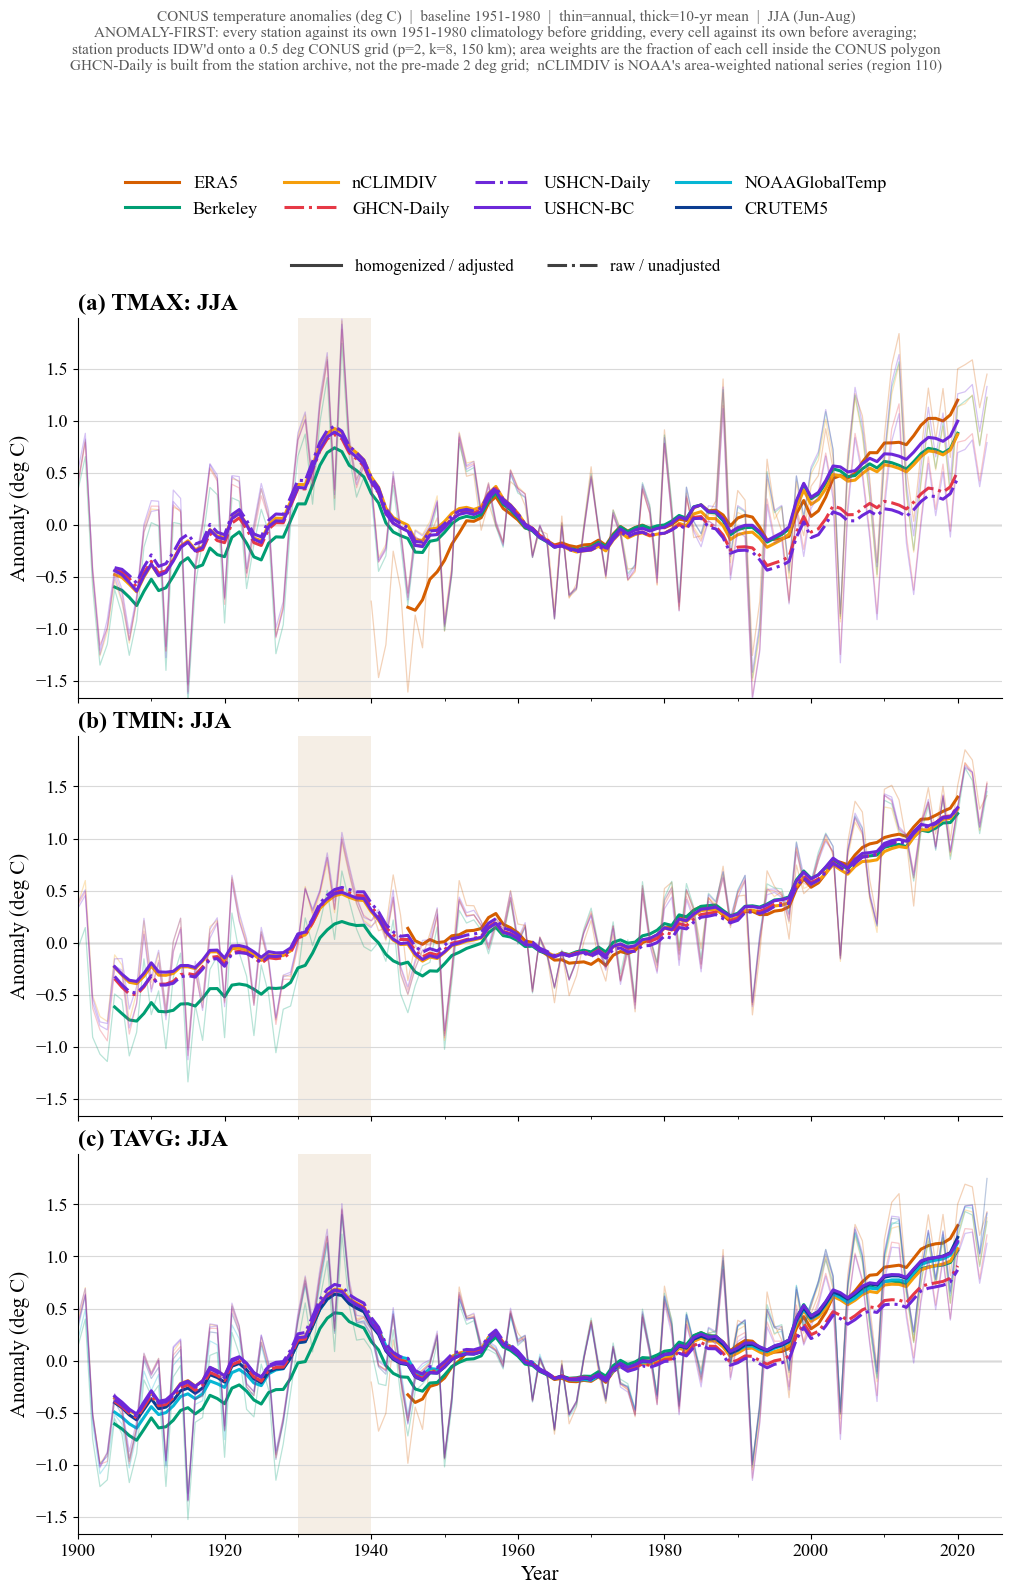

In [23]:
# ══ 6. PLOT (v6/v8 styling, unchanged) ══════════════════════════════════

_all_F1 = [v for k, v in S_F1.items() if v is not None]
_v = np.concatenate([s.dropna().values for s in _all_F1])
_yl_F1 = (max(np.nanquantile(_v, 0.01) - 0.4, -5), min(np.nanquantile(_v, 0.99) + 0.4, 4))

with mpl.rc_context(STYLE_F1):
    fig11, axes11 = plt.subplots(3, 1, figsize=(10, 13), sharex=True,
                                 constrained_layout=True)
    for ax, (elem, title) in zip(axes11, (("tmax", "(a) TMAX: JJA"),
                                          ("tmin", "(b) TMIN: JJA"),
                                          ("tavg", "(c) TAVG: JJA"))):
        ax.axvspan(*DUSTBOWL_F1, color="#caa472", alpha=0.18, lw=0, zorder=0)
        for key in PANEL_SETS_F1[elem]:
            s = S_F1.get((key, elem))
            if s is None:
                continue
            ls = LS_HOMOG_F1 if HOMOG_F1[key] else LS_RAW_F1
            ax.plot(s.index, s.values, color=COL_F1[key], lw=LW_ANN_F1, alpha=ALPHA_ANN_F1)
            ax.plot(s.index, smooth_F1(s).values, color=COL_F1[key], lw=LW_SM_F1,
                    ls=ls, label=LABEL_F1[key])
        ax.axhline(0, color="0.2", lw=0.9, alpha=0.8, zorder=0)
        ax.set_title(title, loc="left", fontweight="bold", fontsize=17)
        ax.set_ylabel("Anomaly (deg C)")
        ax.grid(True, axis="y", color="0.85", lw=0.8); ax.grid(False, axis="x")
        ax.set_ylim(*_yl_F1); ax.set_xlim(1900, 2026)
        ax.tick_params(axis="both", labelsize=13)
    axes11[2].set_xlabel("Year", fontsize=15)
    axes11[2].xaxis.set_major_locator(mticker.MultipleLocator(20))
    axes11[2].xaxis.set_minor_locator(mticker.MultipleLocator(10))

    h11, l11, seen11 = [], [], set()
    for ax in axes11:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in seen11:
                h11.append(h); l11.append(l); seen11.add(l)
    fig11.legend(h11, l11, loc="upper center", ncol=4, frameon=False,
                 bbox_to_anchor=(0.5, 1.10), handlelength=3.0,
                 columnspacing=1.4, fontsize=13)
    fig11.legend(handles=[Line2D([0], [0], color="0.25", lw=LW_SM_F1, ls=LS_HOMOG_F1,
                                 label="homogenized / adjusted"),
                          Line2D([0], [0], color="0.25", lw=LW_SM_F1, ls=LS_RAW_F1,
                                 label="raw / unadjusted")],
                 loc="upper center", ncol=2, frameon=False,
                 bbox_to_anchor=(0.5, 1.035), handlelength=3.0,
                 columnspacing=2.0, fontsize=12)
    fig11.suptitle(
        "CONUS temperature anomalies (deg C)  |  baseline 1951-1980  |  "
        "thin=annual, thick=10-yr mean  |  JJA (Jun-Aug)\n"
        "ANOMALY-FIRST: every station against its own 1951-1980 climatology before "
        "gridding, every cell against its own before averaging;\n"
        "station products IDW'd onto a 0.5 deg CONUS grid (p=2, k=8, 150 km); "
        "area weights are the fraction of each cell inside the CONUS polygon\n"
        "GHCN-Daily is built from the station archive, not the pre-made 2 deg grid;  "
        "nCLIMDIV is NOAA's area-weighted national series (region 110)",
        fontsize=11, color="0.35", y=1.215)
    OUT11 = FIGD / "FigE_v11_jja_only_3x1_anomaly_first_dessler_method.png"
    fig11.savefig(OUT11, bbox_inches="tight", dpi=300, facecolor="white")
    plt.show(); plt.close(fig11)

_rows_F1 = {f"{e}_{k}": S_F1[(k, e)] for (k, e) in S_F1 if S_F1[(k, e)] is not None}
_csv_F1 = OUT11.with_suffix(".csv")
pd.DataFrame(_rows_F1).round(4).rename_axis("year").to_csv(_csv_F1)


## 6. Figure 2 — seasonal bars

Dust Bowl mean, 1936, 2015-2024 mean and 2024, for each season and each element.


In [24]:

warnings.filterwarnings("ignore", category=RuntimeWarning)

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman","Times","STIXGeneral","DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 10, "axes.titlesize": 10.5, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 8,
    "axes.spines.top": False, "axes.spines.right": False, "axes.linewidth": 0.8,
    "xtick.direction": "out", "ytick.direction": "out",
    "xtick.major.size": 3.5, "ytick.major.size": 3.5, "savefig.dpi": 300,
})
CACHE_ANOM.mkdir(exist_ok=True)

# ── Labels (display only; never used in a cache key) ─────────────────────────
UH_LABEL_RAW_F2 = "USHCN-Daily"
UH_LABEL_ADJ_F2 = "USHCN-BC"
BE_LABEL_MSK_F2 = "BE @ USHCN"
BE_NETWORK_F2   = "ushcn"          # footprint for the masked Berkeley leg
BE_MASK_TIME_VARYING_F2 = False    # see the header note
FS_XTICK_V_F2 = None               # None = v15 sizing; 26 declutters the TAVG label row

# ── Settings ─────────────────────────────────────────────────────────────────
YEARS_F2     = np.arange(1900, 2026)      # v15's window; DJF-2025 needs Jan-Feb 2025
SEASONS_F2   = {"DJF":(12,1,2), "MAM":(3,4,5), "JJA":(6,7,8), "SON":(9,10,11)}
SEASON_LIST_F2 = ["DJF","MAM","JJA","SON"]
SEASON_TITLES_F2 = {"DJF":"DJF (Dec-Feb)", "MAM":"MAM (Mar-May)",
                   "JJA":"JJA (Jun-Aug)", "SON":"SON (Sep-Nov)"}
MIN_COV_FRAC_F2  = 0.50    # season dropped if less than this share of CONUS reported
MIN_PERIOD_YRS_F2 = 7      # of the 10 years in a period-mean bar
MAD_K_F2 = 8.0
IDW_F2 = dict(power=2.0, k=8, radius_km=150.0)

DUST_START_F2, DUST_END_F2 = 1930, 1939
YEAR_1936_F2, YEAR_2024_F2 = 1936, 2024
FIXED_MODERN_START_F2, FIXED_MODERN_END_F2 = 2015, 2024

# ── Colours (v15's) ──────────────────────────────────────────────────────────
_BAR_COLS_F2 = ["#009E73", "#06B6D4", "#F59E0B", "#E63946"]

def _mad_filt_F2(s, k=MAD_K_F2):
    v = np.asarray(s.values, float)
    med = np.nanmedian(v); mad = np.nanmedian(np.abs(v-med))
    if not np.isfinite(mad) or mad == 0: return s
    bad = np.isfinite(v) & (np.abs(v-med) > k*1.4826*mad)
    return s.where(~pd.Series(bad, index=s.index)) if bad.any() else s

def _trim_tail_F2(s, z_k=6.0):
    v = np.asarray(s.values, float); fi = np.where(np.isfinite(v))[0]
    if len(fi) < 15: return s
    hist, tail = fi[:-2], fi[-2:]
    if len(hist) < 10: return s
    med = np.nanmedian(v[hist]); mad = np.nanmedian(np.abs(v[hist]-med))
    if not np.isfinite(mad) or mad == 0: return s
    bad = [i for i in tail if np.isfinite(v[i]) and abs(v[i]-med) > z_k*1.4826*mad]
    if not bad: return s
    keep = np.ones_like(v, bool); keep[bad] = False
    return s.where(pd.Series(keep, index=s.index))

def _to_da_F2(s):
    """pandas Series indexed by year -> DataArray on a Jan-1 axis, so the v15
    period-mean helpers below work unchanged."""
    s = s.dropna()
    ti = pd.DatetimeIndex([pd.Timestamp(f"{int(y)}-01-01") for y in s.index])
    return xr.DataArray(s.values, coords=[ti], dims=["time"])

def seasonal_from_field_F2(field, weights, season, gate_coverage=False):
    """cell anomalies -> area mean -> day-weighted season -> QC -> DataArray."""
    m, frac = area_mean(cell_anomalies(field), weights)
    months = SEASONS_F2[season]
    s = pd.Series(season_mean(_to_year_month(m, YEARS_F2), months, YEARS_F2), index=YEARS_F2)
    if gate_coverage:
        f = pd.Series(season_mean(_to_year_month(frac, YEARS_F2), months, YEARS_F2), index=YEARS_F2)
        s = s.where(f >= MIN_COV_FRAC_F2)
    return _to_da_F2(_trim_tail_F2(_mad_filt_F2(s)))

def station_field_F2(dataset, elem, gridder):
    key = (f"grid16_{dataset}_{elem}_p{IDW_F2['power']:g}_k{IDW_F2['k']}"
           f"_r{IDW_F2['radius_km']:g}_{YEARS_F2[0]}_{YEARS_F2[-1]}")
    def build():
        sm = station_anomalies(station_months(dataset, elem, YEARS_F2))
        return grid_station_field(sm, gridder, YEARS_F2)
    return _cache(key, build)

def berkeley_field_F2(fp, elem):
    """All 12 months of monthly means. Read sequentially then subset in memory:
    a lazy month-select does strided reads of a 218 MB file over USB."""
    def build():
        ds = xr.open_dataset(str(fp))
        t = _std(ds["temperature"]).load(); ds.close()
        u = (t.attrs.get("units","") or "").lower()
        if u in ["k","kelvin","degk"] or "kelvin" in u: t = t - 273.15
        m = t.resample(time="MS").mean()
        return m.where(t.resample(time="MS").count() >= MIN_DAYS_MON)
    return _cache(f"field16_berkeley_{elem}", build)

# nCLIMDIV: NOAA's OFFICIAL area-weighted CONUS national mean (region 110).
# Unchanged from v14/v15, which already had this right.
_NCLIMDIV_FILES_F2 = {'tmax':'climdiv-tmaxst-v1.0.0-20260406',
                     'tmin':'climdiv-tminst-v1.0.0-20260406',
                     'tavg':'climdiv-tmpcst-v1.0.0-20260406'}
_NCLIMDIV_ELEM_F2  = {'tmax':27, 'tmin':28, 'tavg':2}

def nclimdiv_seasonal_F2(elem, season):
    fp = NCLIMDIV_DIR / _NCLIMDIV_FILES_F2[elem]
    prefix = f"1100{_NCLIMDIV_ELEM_F2[elem]:02d}"
    ym = np.full((len(YEARS_F2), 12), np.nan)
    with open(str(fp)) as f:
        for line in f:
            if line[:6] == prefix:
                yr = int(line[6:10])
                if not (YEARS_F2[0] <= yr <= YEARS_F2[-1]): continue
                for mo in range(12):
                    v = float(line[10+mo*7:17+mo*7])
                    if v > -90.0: ym[yr-YEARS_F2[0], mo] = (v-32.0)*5.0/9.0
    base = ym[(YEARS_F2 >= BASELINE[0]) & (YEARS_F2 <= BASELINE[1])]
    clim = np.where(np.isfinite(base).sum(0) >= MIN_BASE_CELL, np.nanmean(base, 0), np.nan)
    s = pd.Series(season_mean(ym-clim[None,:], SEASONS_F2[season], YEARS_F2), index=YEARS_F2)
    return _to_da_F2(_trim_tail_F2(_mad_filt_F2(s)))

# ── the masked-Berkeley footprint (v15's rule, unchanged) ────────────────────
def _be_stations_F2():
    st = pd.read_parquet(str(UH_PAIRED), columns=["ushcn_id","lat","lon"])
    st = st.groupby("ushcn_id")[["lat","lon"]].first()
    return st["lat"].values.astype(float), st["lon"].values.astype(float)

def _be_cells_F2(lat, lon, st_lat, st_lon):
    """True where >= 1 station falls inside the cell."""
    lat = np.asarray(lat, float); lon = np.asarray(lon, float)
    oa, oo = np.argsort(lat), np.argsort(lon)
    la, lo = lat[oa], lon[oo]
    dlat = float(np.median(np.diff(la))) if len(la) > 1 else 1.0
    dlon = float(np.median(np.diff(lo))) if len(lo) > 1 else 1.0
    ok = ((st_lat >= la[0]-dlat/2) & (st_lat <= la[-1]+dlat/2)
          & (st_lon >= lo[0]-dlon/2) & (st_lon <= lo[-1]+dlon/2))
    ms = np.zeros((len(la), len(lo)), bool)
    ms[np.clip(np.searchsorted(la+dlat/2, st_lat[ok]), 0, len(la)-1),
       np.clip(np.searchsorted(lo+dlon/2, st_lon[ok]), 0, len(lo)-1)] = True
    m = np.zeros_like(ms); m[np.ix_(oa, oo)] = ms
    return m, int(ok.sum())

# ── v15's period-mean helpers, unchanged ─────────────────────────────────────
def _pm_F2(da, y0, y1, min_yrs=MIN_PERIOD_YRS_F2):
    yrs = da["time"].dt.year.values
    v = np.asarray(da.values, float)[(yrs >= y0) & (yrs <= y1)]
    return float(np.nanmean(v)) if np.isfinite(v).sum() >= min_yrs else np.nan

def _pm_yr_F2(da, year):
    yrs = da["time"].dt.year.values
    v = np.asarray(da.values, float); m = yrs == year
    if m.sum() < 1: return np.nan
    out = float(v[m][0])
    return out if np.isfinite(out) else np.nan


In [25]:
# ══ BUILD EVERY SERIES ══════════════════════════════════════════════════════
_lat05_F2, _lon05_F2 = g05_centers()
W05_F2 = cell_weights(_lat05_F2, _lon05_F2, key="g05")
GRID_F2 = IDWGrid(_lat05_F2, _lon05_F2, **IDW_F2)

SER_F2 = {}                                  # (key, elem, season) -> DataArray
for _ds in ("ghcnd", "ushcn", "ushcn_bc"):
    for _e in ("tmax", "tmin", "tavg"):
        _fld = station_field_F2(_ds, _e, GRID_F2)
        for _s in SEASON_LIST_F2:
            SER_F2[(_ds, _e, _s)] = seasonal_from_field_F2(_fld, W05_F2, _s)

_be_f_F2 = {"tmax": berkeley_field_F2(BE_TMAX, "tmax"),
           "tmin": berkeley_field_F2(BE_TMIN, "tmin")}
if BE_TAVG.exists():
    _be_f_F2["tavg"] = berkeley_field_F2(BE_TAVG, "tavg")
_Wbe_F2 = cell_weights(_be_f_F2["tmax"]["lat"].values, _be_f_F2["tmax"]["lon"].values,
                        key="berkeley")
_st_lat_F2, _st_lon_F2 = _be_stations_F2()
_bemask_F2, _n_in_F2 = _be_cells_F2(_be_f_F2["tmax"]["lat"].values,
                                 _be_f_F2["tmax"]["lon"].values, _st_lat_F2, _st_lon_F2)
_Wbe_msk_F2 = _Wbe_F2.where(xr.DataArray(_bemask_F2, dims=("lat", "lon"),
                                       coords=_Wbe_F2.coords), 0.0)

for _e, _f in _be_f_F2.items():
    for _s in SEASON_LIST_F2:
        SER_F2[("berkeley", _e, _s)] = seasonal_from_field_F2(_f, _Wbe_F2, _s)
        SER_F2[("be_msk", _e, _s)] = seasonal_from_field_F2(_f, _Wbe_msk_F2, _s)
if "tavg" not in _be_f_F2:                    # no Berkeley TAVG file: 0.5*(TMAX+TMIN)
    for _k in ("berkeley", "be_msk"):
        for _s in SEASON_LIST_F2:
            SER_F2[(_k, "tavg", _s)] = 0.5*(SER_F2[(_k, "tmax", _s)]
                                           + SER_F2[(_k, "tmin", _s)])

_noaa_F2 = noaa_field()
_Wno_F2 = cell_weights(_noaa_F2["lat"].values, _noaa_F2["lon"].values, key="noaa")
_cru_F2 = crutem_field()
_Wcr_F2 = cell_weights(_cru_F2["lat"].values, _cru_F2["lon"].values, key="crutem5")
for _s in SEASON_LIST_F2:
    SER_F2[("noaa", "tavg", _s)] = seasonal_from_field_F2(_noaa_F2, _Wno_F2, _s,
                                                        gate_coverage=True)
    SER_F2[("crutem5", "tavg", _s)] = seasonal_from_field_F2(_cru_F2, _Wcr_F2, _s,
                                                           gate_coverage=True)
for _e in ("tmax", "tmin", "tavg"):
    for _s in SEASON_LIST_F2:
        SER_F2[("nclimdiv", _e, _s)] = nclimdiv_seasonal_F2(_e, _s)


In [26]:
# ══ SPECS (v15's bar order; ERA20C dropped -- it was never drawn) ═══════════
LABELS_F2 = {"berkeley": "Berkeley", "be_msk": BE_LABEL_MSK_F2, "nclimdiv": "nCLIMDIV",
            "noaa": "NOAAGlobalTemp", "crutem5": "CRUTEM5", "ghcnd": "GHCN-Daily",
            "ushcn": UH_LABEL_RAW_F2, "ushcn_bc": UH_LABEL_ADJ_F2}
ORDER_F2 = {"tmax": ["berkeley", "be_msk", "nclimdiv", "ghcnd", "ushcn", "ushcn_bc"],
           "tmin": ["berkeley", "be_msk", "nclimdiv", "ghcnd", "ushcn", "ushcn_bc"],
           "tavg": ["berkeley", "be_msk", "nclimdiv", "noaa", "crutem5", "ghcnd",
                    "ushcn", "ushcn_bc"]}

def _yr1936_for_F2(s): return YEAR_1936_F2 + 1 if s == "DJF" else YEAR_1936_F2
def _yr2024_for_F2(s): return YEAR_2024_F2 + 1 if s == "DJF" else YEAR_2024_F2

def _cspec_F2(da, lbl, s):
    if da is None: return None
    modern = _pm_F2(da, FIXED_MODERN_START_F2, FIXED_MODERN_END_F2)
    if not np.isfinite(modern): return None
    return (lbl, _pm_F2(da, DUST_START_F2, DUST_END_F2), _pm_yr_F2(da, _yr1936_for_F2(s)),
            modern, _pm_yr_F2(da, _yr2024_for_F2(s)))

_MISSING_F2 = []
def _specs_F2(elem, s):
    out = []
    for k in ORDER_F2[elem]:
        sp = _cspec_F2(SER_F2.get((k, elem, s)), LABELS_F2[k], s)
        if sp is None:
            _MISSING_F2.append((elem.upper(), s, LABELS_F2[k], "whole series dropped: "
                               "no 2015-2024 mean"))
            continue
        for _bar, _v in ((str(YEAR_1936_F2), sp[2]), (str(YEAR_2024_F2), sp[4])):
            if not np.isfinite(_v):
                _MISSING_F2.append((elem.upper(), s, LABELS_F2[k],
                                   f"{_bar} bar: no value for that season"))
        out.append(sp)
    return out

all_specs_F2 = {(ri, s): _specs_F2(e, s)
               for ri, e in enumerate(("tmax", "tmin", "tavg")) for s in SEASON_LIST_F2}

row_ylims_F2 = []
for ri in range(3):
    vals = [v for s in SEASON_LIST_F2 for sp in all_specs_F2[(ri, s)]
            for v in sp[1:5] if v is not None and np.isfinite(v)]
    row_ylims_F2.append((min(vals)-0.20, max(vals)+0.20) if vals else (-2.0, 2.0))
# ══════════════════════════════════════════════════════════════════════════════


In [27]:
# CHECK -- Figure 2 bars, before plotting. Every bar that will be drawn, JJA TMAX.
print(f"{'dataset':<16}{'DustBowl':>10}{'1936':>8}{'2015-24':>9}{'2024':>8}")
for _lbl, _db, _y36, _md, _y24 in all_specs_F2[(0, "JJA")]:
    _f = lambda v: f"{v:>+8.2f}" if v is not None and np.isfinite(v) else f"{'n/a':>8}"
    print(f"  {_lbl:<14}{_f(_db)[:10]:>10}{_f(_y36)}{_f(_md)[:9]:>9}{_f(_y24)}")
if _MISSING_F2:
    print("\nbars that cannot be drawn (data availability, not a bug):")
    for _e, _s, _lbl, _why in _MISSING_F2:
        print(f"  {_e:<5}{_s:<5}{_lbl:<14}{_why}")
_n_series = sum(1 for _v in SER_F2.values() if _v is not None)
print(f"\n{_n_series} seasonal series built "
      f"({len(ORDER_F2['tavg'])} datasets x {len(SEASON_LIST_F2)} seasons x 3 elements)")


dataset           DustBowl    1936  2015-24    2024
  Berkeley           +0.74   +1.74    +0.88   +1.22
  BE @ USHCN         +0.77   +1.85    +0.82   +1.13
  nCLIMDIV           +0.92   +1.96    +0.87   +1.23
  GHCN-Daily         +0.87   +1.88    +0.51   +0.87
  USHCN-Daily        +0.95   +1.98    +0.44   +0.79
  USHCN-BC           +0.89   +1.92    +0.99   +1.33

bars that cannot be drawn (data availability, not a bug):
  TMAX DJF  Berkeley      2024 bar: no value for that season
  TMAX DJF  BE @ USHCN    2024 bar: no value for that season
  TMAX DJF  GHCN-Daily    2024 bar: no value for that season
  TMAX SON  Berkeley      2024 bar: no value for that season
  TMAX SON  BE @ USHCN    2024 bar: no value for that season
  TMIN DJF  Berkeley      2024 bar: no value for that season
  TMIN DJF  BE @ USHCN    2024 bar: no value for that season
  TMIN DJF  GHCN-Daily    2024 bar: no value for that season
  TMIN SON  Berkeley      2024 bar: no value for that season
  TMIN SON  BE @ USHCN    20

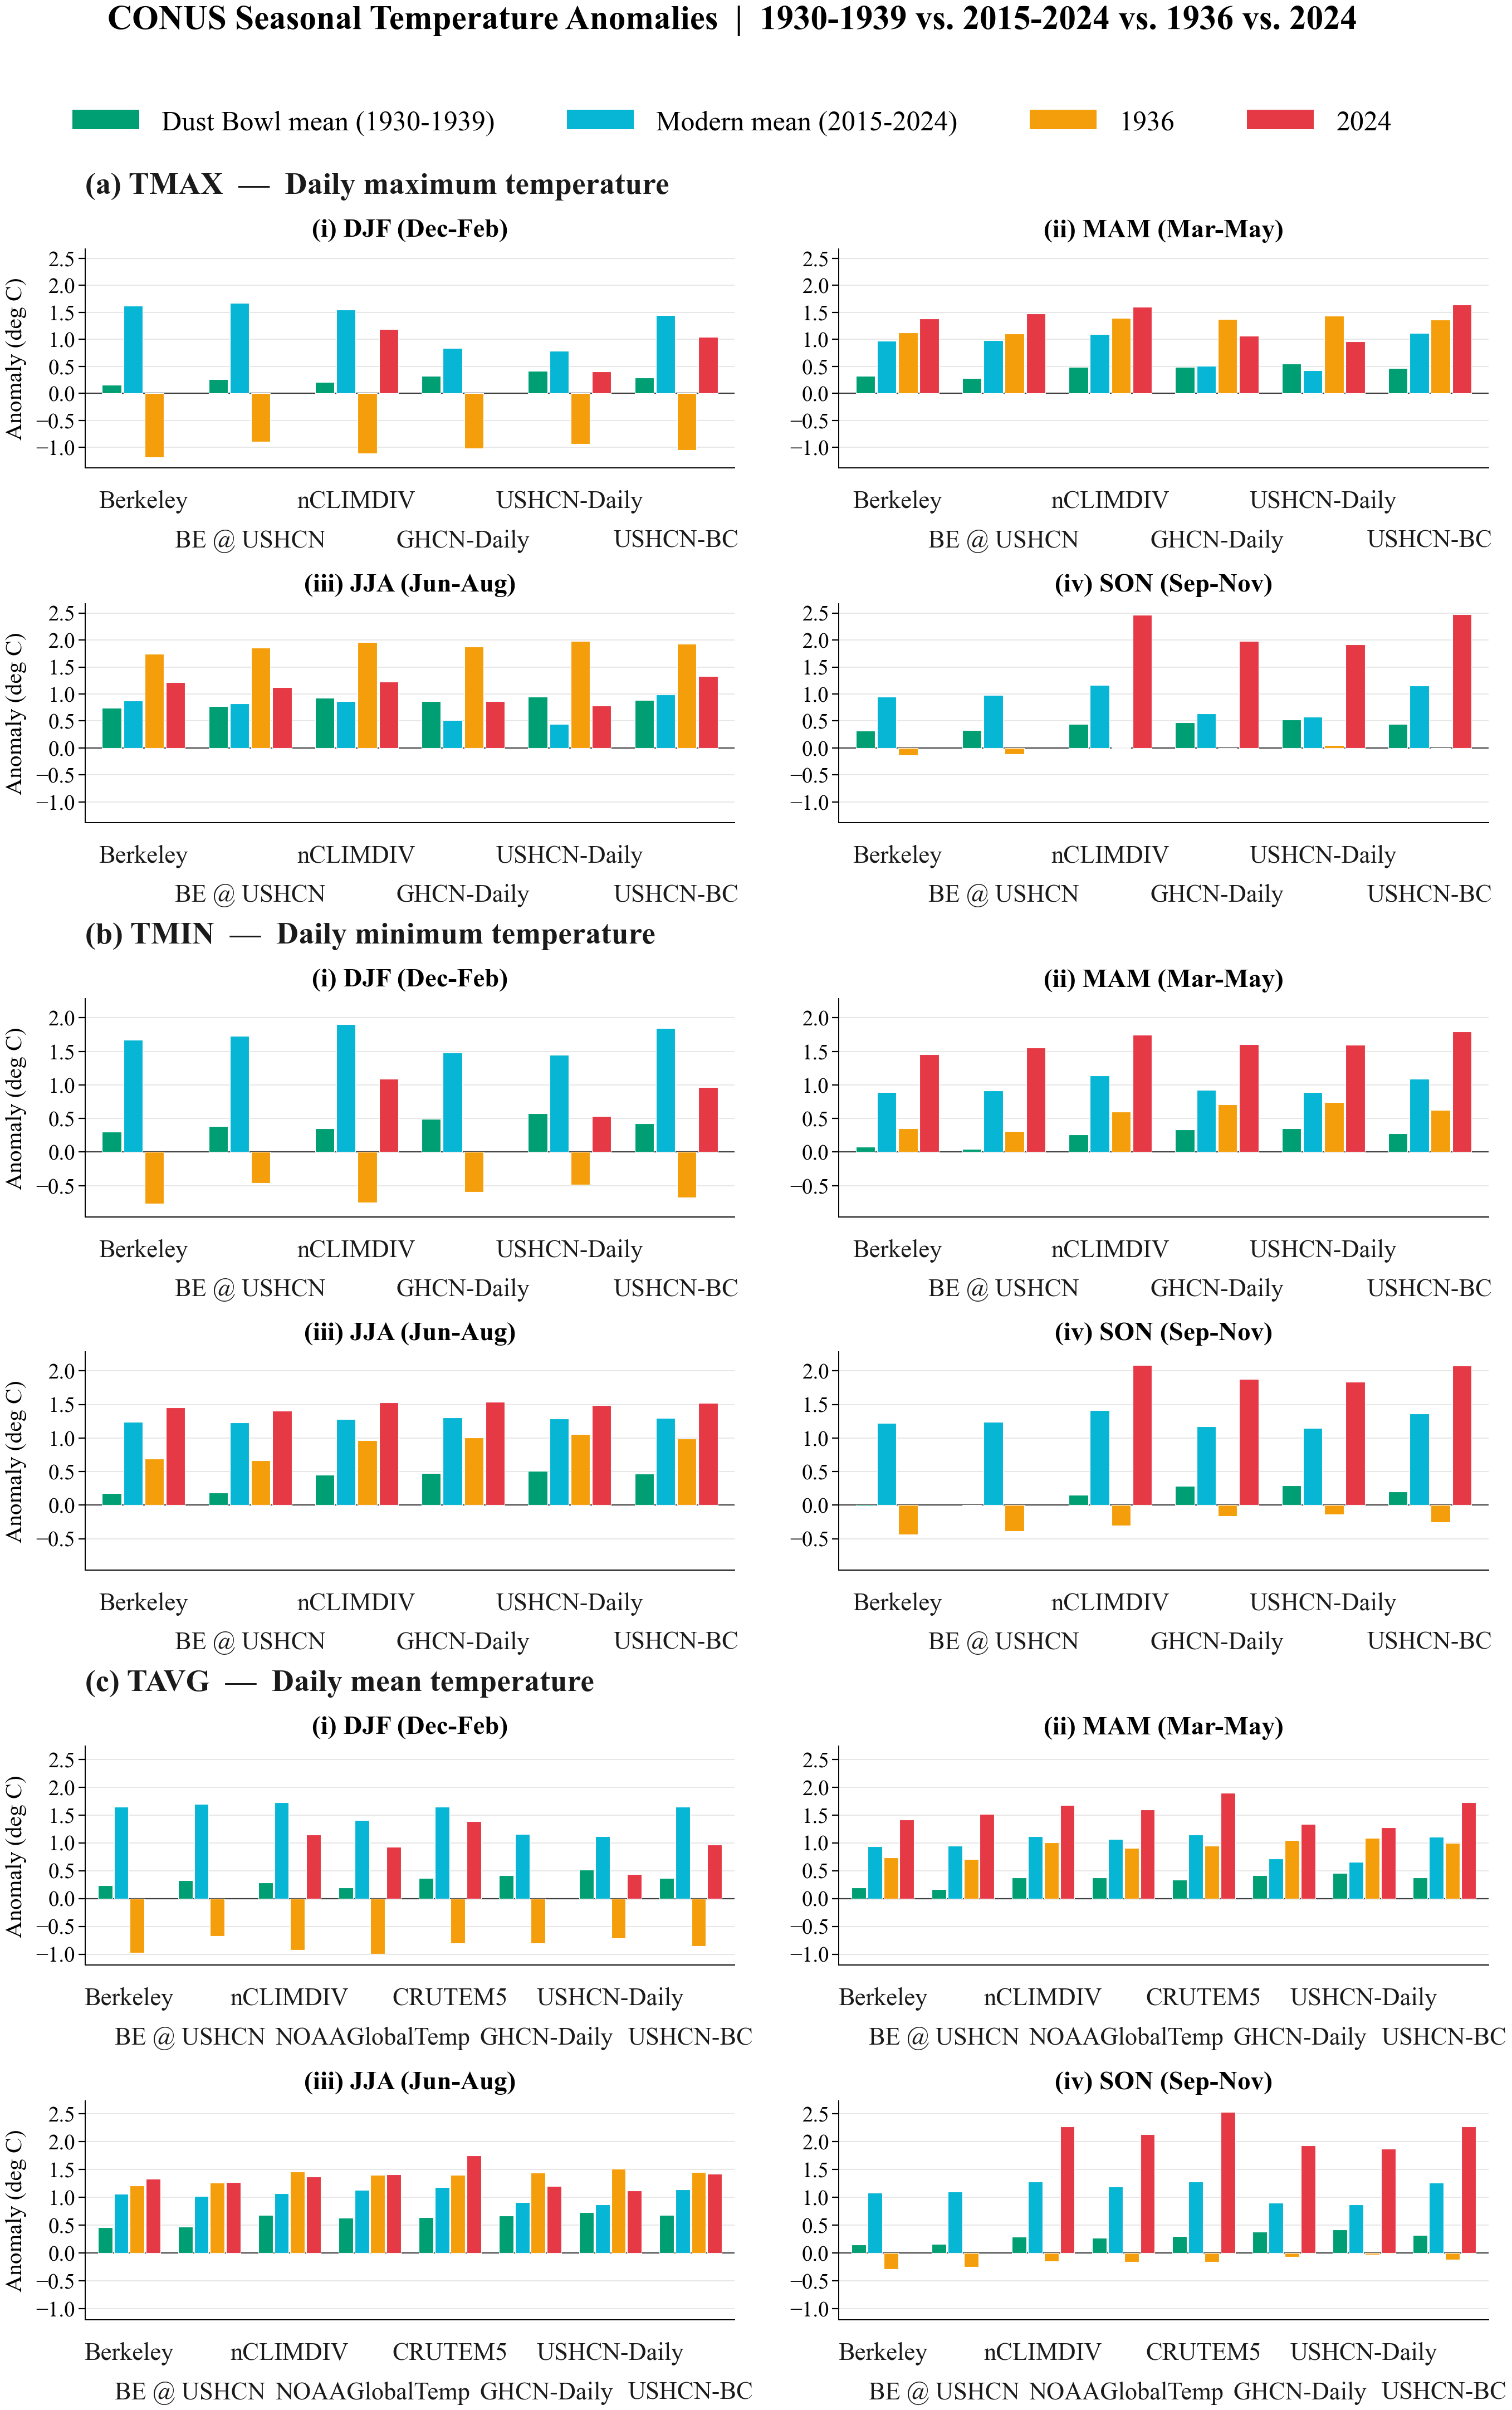

In [28]:
# Plot -- v15's plot block, names suffixed 16. Only the name placement changed
# (see _declutter_names_F2).
# ══════════════════════════════════════════════════════════════════════════════
FS_MAIN_F2, FS_BLOCK_F2, FS_PANEL_F2 = 44, 40, 34
FS_YLABEL_F2, FS_XTICK_F2, FS_YTICK_F2, FS_LEG_F2 = 30, 32, 28, 36

VAR_BLOCK_LABELS_F2 = ["(a) TMAX  —  Daily maximum temperature",
                      "(b) TMIN  —  Daily minimum temperature",
                      "(c) TAVG  —  Daily mean temperature"]
PANEL_LETTERS_F2 = ["i","ii","iii","iv"]
_w_F2, _B_OFF_F2 = 0.18, [-0.30,-0.10,0.10,0.30]
_BEDGE_F2, _BLW_F2, _Y_NM_TIERS_F2 = "white", 0.8, [-0.10,-0.28]
_FS_NM_F2 = FS_XTICK_F2 if FS_XTICK_V_F2 is None else FS_XTICK_V_F2
_BLOCK_BANDS_F2 = [(0.885,0.651),(0.579,0.346),(0.274,0.040)]
_NM_PAD_F2       = 0.12    # minimum gap between same-tier names, in bar-group widths
_NM_MAX_SHIFT_F2 = 0.40    # beyond this sideways drift, shrink the font instead
_NM_MIN_FS_F2    = 24

def _pav_F2(y):
    """least-squares non-decreasing fit (pool-adjacent-violators)."""
    blocks = []
    for v in y:
        blocks.append([float(v), 1])
        while len(blocks) > 1 and blocks[-2][0] > blocks[-1][0]:
            v2, n2 = blocks.pop(); v1, n1 = blocks.pop()
            blocks.append([(v1*n1 + v2*n2)/(n1 + n2), n1 + n2])
    return np.concatenate([[v]*n for v, n in blocks])

def _declutter_names_F2(ax, texts, renderer):
    """texts: list of (x_centre, tier, Text). Moves each same-tier name the
    least total distance so neighbours are >= _NM_PAD_F2 apart; shrinks the font
    only if that would pull a name more than _NM_MAX_SHIFT_F2 off its bars."""
    if not texts: return
    px_per_x = ax.transData.transform((1, 0))[0] - ax.transData.transform((0, 0))[0]
    fs = texts[0][2].get_fontsize()
    while True:
        worst = 0.0; newx = {}
        for tier in {t for _, t, _ in texts}:
            row = sorted([(x, tx) for x, t, tx in texts if t == tier], key=lambda r: r[0])
            x0 = np.array([x for x, _ in row], float)
            hw = np.array([tx.get_window_extent(renderer).width/px_per_x/2 for _, tx in row])
            need = np.concatenate([[0.0], np.cumsum(hw[:-1] + hw[1:] + _NM_PAD_F2)])
            # x_i - need_i must be non-decreasing; project x0 - need onto that
            x = _pav_F2(x0 - need) + need
            for (xc, tx), xn in zip(row, x): newx[id(tx)] = xn
            worst = max(worst, float(np.max(np.abs(x - x0))))
        if worst <= _NM_MAX_SHIFT_F2 or fs <= _NM_MIN_FS_F2:
            break
        fs -= 1
        for _, _, tx in texts: tx.set_fontsize(fs)
    for _, _, tx in texts:
        tx.set_x(newx[id(tx)])

fig_F2 = plt.figure(figsize=(28, 44))
_axes_F2 = {}
_names_F2 = {}
for bi, (band_top, band_bot) in enumerate(_BLOCK_BANDS_F2):
    gs = GridSpec(2, 2, figure=fig_F2, top=band_top, bottom=band_bot,
                  left=0.085, right=0.985, hspace=0.62, wspace=0.16)
    for sub_r in range(2):
        for ci in range(2):
            _axes_F2[(bi, SEASON_LIST_F2[sub_r*2+ci])] = fig_F2.add_subplot(gs[sub_r, ci])
    fig_F2.text(0.085, band_top + 0.020, VAR_BLOCK_LABELS_F2[bi], ha="left", va="bottom",
               fontsize=FS_BLOCK_F2, fontweight="bold", color="0.10")

for bi in range(3):
    for si, s in enumerate(SEASON_LIST_F2):
        ax = _axes_F2[(bi, s)]; specs = all_specs_F2[(bi, s)]; n = len(specs)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(1.4); ax.spines["bottom"].set_linewidth(1.4)
        for xi, (lbl, dust_v, yr36_v, mod_v, yr24_v) in enumerate(specs):
            for off, val, bc in zip(_B_OFF_F2, [dust_v, mod_v, yr36_v, yr24_v], _BAR_COLS_F2):
                if np.isfinite(val):
                    ax.bar(xi+off, val, width=_w_F2, color=bc,
                           edgecolor=_BEDGE_F2, linewidth=_BLW_F2, zorder=3)
        trans = blended_transform_factory(ax.transData, ax.transAxes)
        _names_F2[(bi, s)] = [
            (xi, xi % 2, ax.text(xi, _Y_NM_TIERS_F2[xi % 2], lbl, transform=trans,
                                 ha="center", va="top", fontsize=_FS_NM_F2,
                                 color="0.10", clip_on=False))
            for xi, (lbl, *_) in enumerate(specs)]
        ax.axhline(0, color="0.25", lw=1.6, zorder=2)
        ax.set_xticks(np.arange(n)); ax.tick_params(axis="x", length=0)
        ax.set_xticklabels([]); ax.set_xlim(-0.55, n-0.45)
        ax.set_ylim(*row_ylims_F2[bi])
        ax.grid(True, axis="y", color="0.88", lw=1.1, zorder=0); ax.grid(False, axis="x")
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
        ax.tick_params(axis="y", labelsize=FS_YTICK_F2, length=9, width=1.6)
        if si % 2 == 0:
            ax.set_ylabel("Anomaly (deg C)", fontsize=FS_YLABEL_F2, labelpad=12)
        ax.set_title(f"({PANEL_LETTERS_F2[si]}) {SEASON_TITLES_F2[s]}",
                     fontweight="bold", fontsize=FS_PANEL_F2, pad=16)

_rend_F2 = fig_F2.canvas.get_renderer()
for (bi, s), texts in _names_F2.items():
    _declutter_names_F2(_axes_F2[(bi, s)], texts, _rend_F2)

_leg_handles_F2 = [
    mpatches.Patch(facecolor=_BAR_COLS_F2[0], label=f"Dust Bowl mean ({DUST_START_F2}-{DUST_END_F2})"),
    mpatches.Patch(facecolor=_BAR_COLS_F2[1], label=f"Modern mean ({FIXED_MODERN_START_F2}-{FIXED_MODERN_END_F2})"),
    mpatches.Patch(facecolor=_BAR_COLS_F2[2], label=str(YEAR_1936_F2)),
    mpatches.Patch(facecolor=_BAR_COLS_F2[3], label=str(YEAR_2024_F2)),
]
fig_F2.legend(handles=_leg_handles_F2, loc="upper center", ncol=4, frameon=False,
             bbox_to_anchor=(0.5, 0.952), handlelength=2.4, columnspacing=2.6,
             fontsize=FS_LEG_F2)
fig_F2.text(0.5, 0.972,
           f"CONUS Seasonal Temperature Anomalies  |  {DUST_START_F2}-{DUST_END_F2} vs. "
           f"{FIXED_MODERN_START_F2}-{FIXED_MODERN_END_F2} vs. {YEAR_1936_F2} vs. {YEAR_2024_F2}",
           ha="center", va="bottom", fontsize=FS_MAIN_F2, fontweight="bold")

_out_F2 = (FIGD
          / f"FigH_v16_seasonal_conus_2x2_anomaly_first_plus_BE_at_{BE_NETWORK_F2}_sites_labelfix.png")
_out_F2.parent.mkdir(exist_ok=True)
fig_F2.savefig(_out_F2, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig_F2)


_rows_F2 = {}
for (k, e, s), da in SER_F2.items():
    if da is None: continue
    _rows_F2[f"{e}_{s}_{k}"] = pd.Series(da.values, index=da["time"].dt.year.values)
_csv_F2 = _out_F2.with_suffix(".csv")
pd.DataFrame(_rows_F2).sort_index(axis=1).round(4).rename_axis("year").to_csv(_csv_F2)


## 7. Figure 3 — daily TMAX record frequency

For each station or grid cell and each May-September calendar day, which year holds the highest TMAX of 1900-2024. Ties are split. This section also builds the daily station cube that Figure 6 reads, so run it before section 10.


In [29]:

warnings.filterwarnings("ignore", category=RuntimeWarning)
for _d in (FIGD, CACHE_REC): _d.mkdir(parents=True, exist_ok=True)

Y0_F3, Y1_F3   = 1900, 2024
MONTHS   = [5, 6, 7, 8, 9]
NDAYS    = 153
YEARS_F3    = np.arange(Y0_F3, Y1_F3 + 1)
MIN_YEARS, MIN_FRAC = 100, 0.80
MIN_CELL_FRAC = 0.50             # a Berkeley cell must be >=50% inside CONUS
BE_LAND_MIN   = 0.50             # ... and >50% land in Berkeley's own mask
TMAX_BOUNDS_F3   = (-40.0, 57.0)    # degC; 56.7 is the highest reliable US reading
ROLL = 5
BLANK_PARTIAL = True             # Berkeley's daily release stops 2024-08-31
FORCE_F3 = False
TAG_F3  = f"y{MIN_YEARS}_f{MIN_FRAC:g}_b{TMAX_BOUNDS_F3[0]:g}-{TMAX_BOUNDS_F3[1]:g}"
COV_FP    = CACHE_REC / f"ghcnd_coverage_mjjas_conus_{TAG_F3}.parquet"
DAILY_FP  = CACHE_REC / f"ghcnd_daily_mjjas_conus_{TAG_F3}.npz"
SERIES_FP = CACHE_REC / f"fig3_all_series_{TAG_F3}_cf{MIN_CELL_FRAC:g}.csv"

# the canonical May-September calendar: 125 years x 153 days = 19,125 rows
_t = pd.date_range(f"{Y0_F3}-01-01", f"{Y1_F3}-12-31", freq="D")
_t = _t[np.isin(_t.month, MONTHS)]
KEYS = (_t.year * 10000 + _t.month * 100 + _t.day).to_numpy(np.int64)
KPOS = pd.Index(KEYS)
YR, MO, DY = _t.year.values, _t.month.values, _t.day.values
assert len(KEYS) == len(YEARS_F3) * NDAYS, "calendar is the wrong length"

# ══ THE RECORD KERNEL — one implementation for every line ═══════════════════
def credit(sub):
    """Fractional credit for holding the all-time max of one calendar day.
    N years sharing the maximum get 1/N each -- unbiased and deterministic."""
    fin = np.isfinite(sub); m = np.where(fin, sub, -np.inf)
    match = fin & (m == m.max(axis=0)[None, :])
    n = match.sum(axis=0)
    return np.where(match, 1.0 / np.where(n > 0, n, 1)[None, :], 0.0)

def record_counts(vals, yr, mo, dy):
    """(n_year, n_unit) all-time record counts. `vals` is (n_time, n_unit)."""
    ymap = {y: i for i, y in enumerate(YEARS_F3)}
    out = np.zeros((len(YEARS_F3), vals.shape[1]))
    for m in MONTHS:
        for d in np.unique(dy[mo == m]):
            k = (mo == m) & (dy == d)
            if k.sum() < 2:
                continue
            sub = vals[k]
            if not np.isfinite(sub).any():
                continue
            rows = np.array([ymap[y] for y in yr[k]])
            assert np.unique(rows).size == rows.size, "repeated years on one date"
            np.add.at(out, rows, credit(sub))
    return out

def coverage(vals, yr):
    """(n_years_with_data, frac_of_possible_days) per unit."""
    fin = np.isfinite(vals)
    has = np.zeros((len(YEARS_F3), vals.shape[1]), bool)
    for i, y in enumerate(YEARS_F3):
        s = yr == y
        if s.any():
            has[i] = fin[s].any(axis=0)
    return has.sum(axis=0), fin.sum(axis=0) / float(len(YEARS_F3) * NDAYS)

def complete(ny, fr):
    return (ny >= MIN_YEARS) & (fr >= MIN_FRAC)

def to_series(counts_arr, keep, w=None, label="", check=True):
    c = counts_arr[:, keep]
    ww = np.ones(c.shape[1]) if w is None else np.asarray(w)[keep]
    s = pd.Series((c * ww[None, :]).sum(axis=1) / ww.sum(), index=YEARS_F3)
    integ = float(s.sum())
    if check:
        assert abs(integ - NDAYS) < 0.5, (
            f"{label}: integral {integ:.2f} != {NDAYS}. Every unit must contribute "
            f"exactly one record per day-of-year it observed -- a masking or "
            f"kernel bug, not a result.")
    return s

def ratio(s):
    a = float(s.loc[1930:1939].mean()); b = float(np.nanmean(s.loc[2015:2024]))
    return a, b, a / b

def conus_cell_fraction(lat_c, lon_c, key):
    """Fraction of each grid cell inside CONUS -- the same polygon the stations
    are tested against, so the two domains cannot disagree."""
    fp = CACHE_REC / f"conusfrac_poly_{key}.npy"
    if fp.exists():
        return np.load(fp)
    import shapely
    from shapely.geometry import box as sbox
    poly = conus_polygon()
    la, lo = _edges(lat_c), _edges(lon_c)
    frac = np.zeros((len(lat_c), len(lon_c)))
    cells, idx = [], []
    for i in range(len(lat_c)):
        for j in range(len(lon_c)):
            cells.append(sbox(min(lo[j], lo[j + 1]), min(la[i], la[i + 1]),
                              max(lo[j], lo[j + 1]), max(la[i], la[i + 1])))
            idx.append((i, j))
    tree = shapely.STRtree(np.array(cells, dtype=object))
    for h in np.atleast_1d(tree.query(poly, predicate="intersects")):
        i, j = idx[h]; c = cells[h]
        frac[i, j] = poly.intersection(c).area / c.area if c.area > 0 else 0.0
    np.save(fp, frac)
    return frac


In [30]:
# CHECK -- the record kernel on synthetic numbers. Needs no data files.
# 1. ties are split, not given to the earliest year
_sub = np.array([[1.0], [3.0], [3.0], [np.nan]])          # 4 years, 1 unit, 2-way tie
_c = credit(_sub)
assert np.allclose(_c.ravel(), [0.0, 0.5, 0.5, 0.0]), _c.ravel()
print(f"credit: a two-way tie gives {_c[1, 0]:.2f} / {_c[2, 0]:.2f}, not 1 / 0")

# 2. a clear winner takes the whole day
_sub2 = np.array([[1.0], [5.0], [3.0]])
assert np.allclose(credit(_sub2).ravel(), [0.0, 1.0, 0.0])

# 3. conservation: one unit with a full record holds exactly 153 records
_rng = np.random.default_rng(0)
_v = _rng.normal(30.0, 5.0, size=(len(KEYS), 1)).astype(np.float32)
_cnt = record_counts(_v, YR, MO, DY)
assert abs(_cnt.sum() - NDAYS) < 1e-6, _cnt.sum()
print(f"record_counts: a complete synthetic station holds {_cnt.sum():.1f} records "
      f"(= {NDAYS} May-September days), spread over {(_cnt > 0).sum()} years")

# 4. the completeness rule: years present and fraction of possible days
_v2 = _v.copy(); _v2[: len(KEYS) // 2] = np.nan        # drop the first half of the record
_ny, _fr = coverage(_v2, YR)
assert not complete(_ny, _fr)[0], "a station missing half its record must fail"
print(f"coverage/complete: half a record -> {int(_ny[0])} years, {_fr[0]:.2f} of days, "
      f"rejected (needs >= {MIN_YEARS} years and {MIN_FRAC:.0%} of days)")
print("\nrecord kernel checks passed")


credit: a two-way tie gives 0.50 / 0.50, not 1 / 0
record_counts: a complete synthetic station holds 153.0 records (= 153 May-September days), spread over 89 years
coverage/complete: half a record -> 63 years, 0.50 of days, rejected (needs >= 100 years and 80% of days)

record kernel checks passed


In [31]:
# ══ (1) GHCN-DAILY, FROM THE STATION ARCHIVE ═══════════════════════════════
inv = pd.read_fwf(str(GHCND_INV),
                  colspecs=[(0, 11), (12, 20), (21, 30), (31, 35), (36, 40), (41, 45)],
                  names=["id", "lat", "lon", "elem", "y0", "y1"])
inv = inv[inv["elem"] == "TMAX"]
inv = inv[inv["lat"].between(BOX["lat_min"], BOX["lat_max"])
          & inv["lon"].between(BOX["lon_min"], BOX["lon_max"])]
POS = inv.groupby("id")[["lat", "lon"]].first()
_n_box = len(POS)
POS = POS[points_inside(POS["lat"].to_numpy(), POS["lon"].to_numpy())]
CANDIDATES = set(POS.index)

YRS_PRESENT = [y for y in range(Y0_F3, Y1_F3 + 1)
               if (GHCND_GLOBAL / f"ghcn_global_{y}.parquet").exists()]

_QCOLS = None
def read_year(y, keep_ids=None):
    """MJJAS TMAX for one year: QC'd, deduplicated, CONUS stations only."""
    global _QCOLS
    fp = GHCND_GLOBAL / f"ghcn_global_{y}.parquet"
    if _QCOLS is None:
        avail = set(pd.read_parquet(fp).head(0).columns)
        _QCOLS = [c for c in ("qflag", "q_flag", "tmax_qflag", "quality_flag")
                  if c in avail]
    d = pd.read_parquet(fp, columns=["station_id", "date", "tmax_c"] + _QCOLS)
    d = d[d["tmax_c"].notna()]
    d = d[d["station_id"].isin(keep_ids if keep_ids is not None else CANDIDATES)]
    if d.empty:
        return d
    for c in _QCOLS:                       # a non-empty flag means the value failed
        d = d[d[c].fillna("").astype(str).str.strip() == ""]
    d = d[d["tmax_c"].between(*TMAX_BOUNDS_F3)]
    dt = pd.DatetimeIndex(d["date"])
    d = d[np.isin(dt.month, MONTHS)]
    if d.empty:
        return d
    return d.drop_duplicates(subset=["station_id", "date"], keep="first")

if COV_FP.exists() and not FORCE_F3:
    cov = pd.read_parquet(COV_FP)
else:
    per_year = {}
    for y in YRS_PRESENT:
        d = read_year(y)
        per_year[y] = (d.groupby("station_id").size().astype("int32")
                       if not d.empty else pd.Series(dtype="int32"))
    cov = pd.DataFrame(per_year).fillna(0).astype("int32")
    cov.to_parquet(COV_FP)

_ny = (cov > 0).sum(axis=1)
_fr = cov.sum(axis=1) / float(len(YEARS_F3) * NDAYS)
KEEP_IDS = cov.index[complete(_ny, _fr)]

if DAILY_FP.exists() and not FORCE_F3:
    z = np.load(DAILY_FP, allow_pickle=False); IDS, V = z["ids"], z["values"]
else:
    IDS = np.asarray(sorted(KEEP_IDS), dtype="<U11")
    IPOS = pd.Index(IDS); want = set(IDS.tolist())
    V = np.full((len(KEYS), len(IDS)), np.nan, np.float32)
    for y in YRS_PRESENT:
        d = read_year(y, keep_ids=want)
        if d.empty:
            continue
        dt = pd.DatetimeIndex(d["date"])
        key = (dt.year * 10000 + dt.month * 100 + dt.day).to_numpy(np.int64)
        r = KPOS.get_indexer(key); c = IPOS.get_indexer(d["station_id"].to_numpy())
        g = (r >= 0) & (c >= 0)
        V[r[g], c[g]] = d["tmax_c"].to_numpy(np.float32)[g]
    np.savez_compressed(DAILY_FP, ids=IDS, values=V)

_all_gh = np.ones(len(IDS), bool)
ghcnd = to_series(record_counts(V, YR, MO, DY), _all_gh, label="GHCN-Daily")

# ══ (2) THE MATCHED USHCN PAIR ═════════════════════════════════════════════
_mt = "".join(map(str, MONTHS))
piv = {}
for w in ("raw", "adj"):
    p = pd.read_parquet(str(UH_PIV_DIR / f"ushcn_pair_tmax_pivot_m{_mt}_{w}.parquet"))
    p.index = pd.DatetimeIndex(p.index); piv[w] = p
_cols = piv["raw"].columns.intersection(piv["adj"].columns)
piv = {w: p.reindex(columns=_cols) for w, p in piv.items()}
assert np.array_equal(np.isfinite(piv["raw"].values), np.isfinite(piv["adj"].values)), \
    ("raw and adjusted USHCN pivots are not on the same days -- rebuild them. The "
     "whole point of this pair is that the adjustment is the ONLY difference.")
_ut = pd.DatetimeIndex(piv["raw"].index)
_us = np.isin(_ut.month, MONTHS) & (_ut.year >= Y0_F3) & (_ut.year <= Y1_F3)
UYR, UMO, UDY = _ut.year.values[_us], _ut.month.values[_us], _ut.day.values[_us]
RAW, ADJ = piv["raw"].values[_us], piv["adj"].values[_us]
_uny, _ufr = coverage(RAW, UYR)            # identical for ADJ by construction
KEEP_UH = complete(_uny, _ufr)
ushcn    = to_series(record_counts(RAW, UYR, UMO, UDY), KEEP_UH, label="USHCN-Daily")
ushcn_bc = to_series(record_counts(ADJ, UYR, UMO, UDY), KEEP_UH, label="USHCN-BC")

# ══ (3) BERKELEY, AND BERKELEY AT THE GHCN-DAILY STATIONS ══════════════════
_ds = xr.open_dataset(str(BE_TMAX))
_da = _ds["temperature"]
_bt = pd.DatetimeIndex(_da["time"].values)
BLAT = _ds["latitude"].values.astype(float)
BLON = _ds["longitude"].values.astype(float)
if BLON.max() > 180.0:
    BLON = np.where(BLON > 180.0, BLON - 360.0, BLON)
_bland = _ds["land_mask"]
_bland = (_bland.isel(time=0) if "time" in _bland.dims else _bland).values
_bs = np.isin(_bt.month, MONTHS) & (_bt.year >= Y0_F3) & (_bt.year <= Y1_F3)
BV = _da.values[_bs].reshape(int(_bs.sum()), -1)
BYR, BMO, BDY = _bt.year.values[_bs], _bt.month.values[_bs], _bt.day.values[_bs]
_blast = _bt[-1]
_ds.close()
PARTIAL = [] if (_blast.month == 12 and _blast.day == 31) else [int(_blast.year)]

_bfrac = conus_cell_fraction(BLAT, BLON, "berkeley").ravel()
_bny, _bfr = coverage(BV, BYR)
KEEP_BE = (_bfrac >= MIN_CELL_FRAC) & (_bland.ravel() > BE_LAND_MIN) & complete(_bny, _bfr)
_bcounts = record_counts(BV, BYR, BMO, BDY)
berkeley = to_series(_bcounts, KEEP_BE, w=_bfrac, label="Berkeley Earth")

# each kept GHCN-Daily station carries its own Berkeley cell. ONE UNIT PER
# STATION, counted at the point. Duplicates are kept on purpose: two stations in
# one cell means that cell counts twice, which is exactly the density weighting
# the station network imposes and the effect this line exists to expose.
_kpos = POS.loc[POS.index.intersection(pd.Index(IDS))]
_il = np.rint((_kpos["lat"].to_numpy() - BLAT[0]) / (BLAT[1] - BLAT[0])).astype(int)
_io = np.rint((_kpos["lon"].to_numpy() - BLON[0]) / (BLON[1] - BLON[0])).astype(int)
_ok = (_il >= 0) & (_il < len(BLAT)) & (_io >= 0) & (_io < len(BLON))
_flat = np.ravel_multi_index((_il[_ok], _io[_ok]), (len(BLAT), len(BLON)))
_flat = _flat[KEEP_BE[_flat]]
be_at = to_series(record_counts(BV[:, _flat], BYR, BMO, BDY),
                  np.ones(len(_flat), bool),
                  label="Berkeley Earth at GHCN Stations")

# sensitivities on that construction, printed only
_cells = KEEP_BE & np.isin(np.arange(KEEP_BE.size), np.unique(_flat))
be_at_cells = to_series(_bcounts, _cells, w=_bfrac,
                        label="  [sens] at 1-deg cells instead")
_bkeys = (BYR.astype(np.int64) * 10000 + BMO * 100 + BDY)
_rowmap = KPOS.get_indexer(_bkeys)
_avail = np.zeros((len(_bkeys), len(_flat)), bool)
_g = _rowmap >= 0
_stncol = np.nonzero(_ok)[0][KEEP_BE[np.ravel_multi_index(
    (_il[_ok], _io[_ok]), (len(BLAT), len(BLON)))]]
_avail[_g] = np.isfinite(V[_rowmap[_g]][:, _stncol])
be_at_masked = to_series(record_counts(np.where(_avail, BV[:, _flat], np.nan),
                                       BYR, BMO, BDY),
                         np.ones(len(_flat), bool),
                         label="  [sens] + masked to reporting days", check=False)

if BLANK_PARTIAL and PARTIAL:
    for _s in (berkeley, be_at, be_at_cells, be_at_masked):
        _s.loc[[y for y in PARTIAL if y in _s.index]] = np.nan

SER = {"GHCN-Daily": ghcnd, "USHCN-Daily": ushcn, "Berkeley Earth": berkeley,
       "USHCN-BC": ushcn_bc, "Berkeley Earth at GHCN Stations": be_at}
NU  = {"GHCN-Daily": len(IDS), "USHCN-Daily": int(KEEP_UH.sum()),
       "Berkeley Earth": int(KEEP_BE.sum()), "USHCN-BC": int(KEEP_UH.sum()),
       "Berkeley Earth at GHCN Stations": len(_flat)}

pd.DataFrame(SER).rename_axis("year").to_csv(SERIES_FP)


In [32]:
# CHECK -- Figure 3 series. Each series must integrate to 153: every location
# holds exactly one record per calendar day it observed. to_series asserts this
# while building, so reaching this cell already proves it.
def _ratio_F3(d):
    _a = float(d.loc[1930:1939].mean()); _b = float(np.nanmean(d.loc[2015:2024]))
    return _a, _b, _a / _b
print(f"{'dataset':<34}{'units':>8}{'1930s':>8}{'2015-24':>9}{'ratio':>7}{'integral':>10}")
for _lbl, _s in SER.items():
    _a, _b, _r = _ratio_F3(_s)
    print(f"  {_lbl:<32}{NU[_lbl]:>8,}{_a:>8.2f}{_b:>9.2f}{_r:>7.2f}{float(np.nansum(_s)):>10.1f}")
print("\nratio above 1.00 means the Dust Bowl set more records than the last decade")


dataset                              units   1930s  2015-24  ratio  integral
  GHCN-Daily                         1,257    3.53     1.06   3.31     153.0
  USHCN-Daily                          790    3.38     1.03   3.28     153.0
  Berkeley Earth                       819    2.60     2.31   1.13     151.3
  USHCN-BC                             790    3.05     1.54   1.99     153.0
  Berkeley Earth at GHCN Stations    1,221    3.33     1.87   1.78     151.9

ratio above 1.00 means the Dust Bowl set more records than the last decade


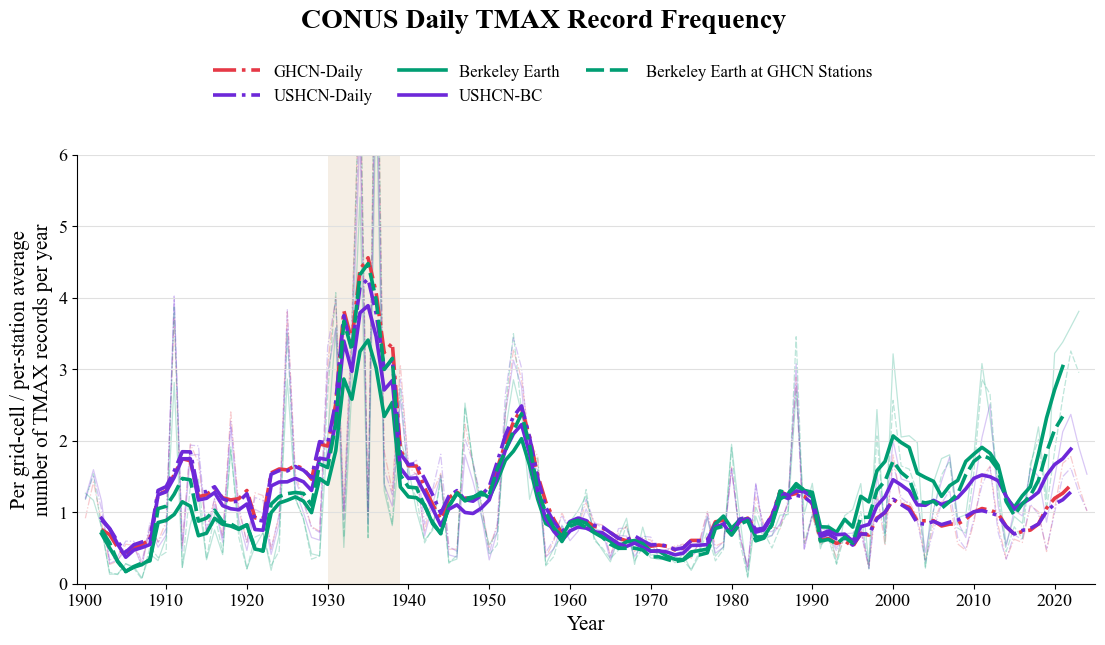

In [33]:
# ══ PLOTS ══════════════════════════════════════════════════════════════════
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix", "font.size": 14, "axes.labelsize": 15,
    "xtick.labelsize": 13, "ytick.labelsize": 13,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.8, "savefig.dpi": 300})
roll = lambda s: s.rolling(ROLL, center=True, min_periods=ROLL).mean()
COL_BE_F3, COL_GH_F3, COL_UH = "#009E73", "#E63946", "#6D28D9"
LINES = [("GHCN-Daily",                      ghcnd,    COL_GH_F3, "-."),
         ("USHCN-Daily",                     ushcn,    COL_UH, "-."),
         ("Berkeley Earth",                  berkeley, COL_BE_F3, "-"),
         ("USHCN-BC",                        ushcn_bc, COL_UH, "-"),
         ("Berkeley Earth at GHCN Stations",  be_at,   COL_BE_F3, (0, (5, 1.6)))]

# no constrained_layout: it fights the figure-level legend and clips the title
fig = plt.figure(figsize=(11.5, 6.6))
fig.subplots_adjust(left=0.095, right=0.98, top=0.755, bottom=0.105)
ax = fig.add_subplot(111)
ax.axvspan(1930, 1939, color="tan", alpha=0.22, lw=0, zorder=0)
for _l, _s, _c, _ls in LINES:
    ax.plot(_s.index, _s.values, color=_c, lw=0.9, ls=_ls, alpha=0.26, zorder=1)
for _l, _s, _c, _ls in LINES:
    ax.plot(_s.index, roll(_s).values, color=_c, lw=2.6, ls=_ls, label=_l, zorder=3)
ax.set_xlim(1899, 2025)
ax.set_ylim(0, 6)
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
ax.set_xlabel("Year")
ax.set_ylabel("Per grid-cell / per-station average\nnumber of TMAX records per year")
ax.grid(True, axis="y", color="0.88", lw=0.8)
ax.grid(False, axis="x")
h, l = ax.get_legend_handles_labels()
fig.legend(h, l, loc="upper center", bbox_to_anchor=(0.5, 0.915), ncol=3,
           frameon=False, handlelength=2.8, columnspacing=1.6, fontsize=12)
fig.suptitle("CONUS Daily TMAX Record Frequency",
             fontsize=20, fontweight="bold", y=0.975)
OUT_F3 = FIGD / f"Fig3_final_{TAG_F3}_roll{ROLL}_ylim0-6.png"
fig.savefig(OUT_F3, bbox_inches="tight", dpi=300, facecolor="white")
fig.savefig(OUT_F3.with_suffix(".pdf"), bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)


## 8. Figure 4 — spatial exceedance maps

Share of JJA days above each cell's own day-of-year 95th percentile, with the threshold taken from the whole record rather than 1951-1980.


In [34]:
warnings.filterwarnings('ignore')
FIGD.mkdir(exist_ok=True)
CACHE_MAPS.mkdir(parents=True, exist_ok=True)

# ─── constants ────────────────────────────────────────────────────────────────
_WARM   = [6, 7, 8]           # JJA only
_WIN    = 31
_DUST_YRS = list(range(1930, 1940))
_CLIM_THRESH = 5.0   # expected exceedance rate for p95 threshold; shown in grey
_DIFF_VMIN   = -20.0
_DIFF_VMAX   =  35.0

# ─── auto-detect available record span ────────────────────────────────────────
_BE_FILES = sorted(BE_RAW.glob('Complete_TMAX_Daily_LatLong1_*.nc'))
if _BE_FILES:
    with xr.open_dataset(_BE_FILES[-1]) as _ds_last:
        _max_year = int(_ds_last['year'].values.max())
    with xr.open_dataset(_BE_FILES[0]) as _ds_first:
        _min_year = int(_ds_first['year'].values.min())
else:
    _min_year, _max_year = 1900, 2024
_MOD_YRS = list(range(_max_year - 9, _max_year + 1))

# ── the change: baseline is the ENTIRE record, not 1951-1980 ──────────────────
_BASE_S, _BASE_E = _min_year, _max_year

# ─── coordinate helpers ───────────────────────────────────────────────────────
def _std_maps(obj):
    rename = {old: new for old, new in [('latitude', 'lat'), ('longitude', 'lon')]
              if old in obj.dims or old in obj.coords}
    return obj.rename(rename) if rename else obj

def _negpos(obj):
    if 'lon' in obj.coords and float(obj['lon'].max()) > 180:
        obj = obj.assign_coords(lon=((obj['lon'] + 180) % 360) - 180).sortby('lon')
    return obj

# ─── target grid ──────────────────────────────────────────────────────────────
_LATS = np.arange(24.5, 50.0, 1.0)
_LONS = np.arange(-179.5, 180.0, 1.0)

# ─── land mask ────────────────────────────────────────────────────────────────
with xr.open_dataset(BE_RAW / 'Complete_TMAX_Daily_LatLong1_1900.nc') as _ds0:
    _lm = _std_maps(_negpos(_ds0['land_mask']))
    _LMASK = (_lm.interp(lat=_LATS, lon=_LONS, method='nearest')
               .fillna(0).values >= 0.5)

# ─── DOY-p95 threshold builder ───────────────────────────────────────────────
# (identical to the 1951-80 version, including the +1 DOY window convention, so
#  the only difference between the two figures is the years that go in)
def _build_thr(data_b, doy_b, cp, doy_cp):
    half = _WIN // 2
    thr_arr, doy_list = [], []
    for d in np.unique(doy_b):
        window = [int((d - half + k) % 366 + 1) for k in range(_WIN)
                  if (d - half + k) % 366 + 1 != 0]
        mw = np.isin(doy_b, window)
        t = (np.nanpercentile(data_b[mw], 95, axis=0).astype(np.float32)
             if mw.sum() > 0 else np.full(data_b.shape[1:], np.nan, np.float32))
        thr_arr.append(t)
        doy_list.append(int(d))
    np.save(cp, np.stack(thr_arr))
    np.save(doy_cp, np.array(doy_list))
    return dict(zip(doy_list, thr_arr))

# ─── Berkeley Earth thresholds (cached, JJA-specific, FULL RECORD) ───────────
_cp_be     = CACHE_MAPS / f'thr_be_jja_fullrecord_{_BASE_S}_{_BASE_E}.npy'
_doy_cp_be = CACHE_MAPS / f'thr_be_jja_fullrecord_{_BASE_S}_{_BASE_E}_doys.npy'

if _cp_be.exists() and _doy_cp_be.exists():
    _THR = dict(zip(np.load(_doy_cp_be).astype(int),
                    np.load(_cp_be, allow_pickle=False)))
else:
    _all_data, _all_doys = [], []
    for fp in _BE_FILES:
        with xr.open_dataset(fp) as ds:
            mon_arr = ds['month'].values.astype(int)
            doy_arr = ds['day_of_year'].values.astype(int)
            be_lats = ds['latitude'].values
            sel = np.isin(mon_arr, _WARM)          # every year in the file
            if not sel.any():
                continue
            t_idx   = np.where(sel)[0]
            lat_idx = np.clip(np.searchsorted(be_lats, _LATS), 0, len(be_lats) - 1)
            # read only the JJA days and only the target latitude band, so the
            # whole-record stack stays small enough to hold in memory
            temp = ds['temperature'].isel(time=t_idx, latitude=lat_idx).values
            clim = ds['climatology'].isel(latitude=lat_idx).values
        cidx  = np.clip(doy_arr[sel] - 1, 0, 364)
        _all_data.append((temp + clim[cidx]).astype(np.float32))
        _all_doys.append(doy_arr[sel])
        del temp, clim
    _THR = _build_thr(np.concatenate(_all_data), np.concatenate(_all_doys),
                      _cp_be, _doy_cp_be)
    del _all_data, _all_doys

# ─── Berkeley Earth year loader ───────────────────────────────────────────────
def _load_be(yr):
    decade = (yr // 10) * 10
    fp = BE_RAW / f'Complete_TMAX_Daily_LatLong1_{decade}.nc'
    if not fp.exists():
        return None
    with xr.open_dataset(fp) as ds:
        yr_arr  = ds['year'].values.astype(int)
        mon_arr = ds['month'].values.astype(int)
        doy_arr = ds['day_of_year'].values.astype(int)
        temp    = ds['temperature'].values
        clim    = ds['climatology'].values
        be_lats = ds['latitude'].values
    sel = (yr_arr == yr) & np.isin(mon_arr, _WARM)
    if not sel.any():
        return None
    cidx    = np.clip(doy_arr[sel] - 1, 0, 364)
    abs_t   = temp[sel] + clim[cidx]
    lat_idx = np.clip(np.searchsorted(be_lats, _LATS), 0, len(be_lats) - 1)
    return abs_t[:, lat_idx, :], doy_arr[sel]


In [35]:
# ─── spatial exceedance computation ──────────────────────────────────────────
def _spatial(years, cache_path, force=False):
    if cache_path.exists() and not force:
        return np.load(cache_path)
    yearly = []
    for yr in years:
        res = _load_be(yr)
        if res is None:
            continue
        data_yr, doys = res
        exc_sum = np.zeros((len(_LATS), len(_LONS)), dtype=float)
        n = 0
        for t_i, d in enumerate(doys):
            dk = int(d)
            if dk not in _THR:
                continue
            t   = _THR[dk]
            exc = (data_yr[t_i] > t).astype(float)
            exc[np.isnan(t)] = np.nan
            exc_sum += np.where(np.isnan(exc), 0, exc)
            n += 1
        if n > 0:
            yearly.append(exc_sum / n * 100)
    result = np.nanmean(yearly, axis=0) if yearly else np.full(
        (len(_LATS), len(_LONS)), np.nan)
    result[~_LMASK] = np.nan
    np.save(cache_path, result)
    return result

_tag = f'fullrec{_BASE_S}_{_BASE_E}'
_dust_cache = CACHE_MAPS / f'spatial_be_jja_dustbowl_{_DUST_YRS[0]}_{_DUST_YRS[-1]}_{_tag}.npy'
_mod_cache  = CACHE_MAPS / f'spatial_be_jja_modern_{_MOD_YRS[0]}_{_MOD_YRS[-1]}_{_tag}.npy'

_map_dust = _spatial(_DUST_YRS, _dust_cache)
_map_mod  = _spatial(_MOD_YRS,  _mod_cache)
_map_diff = _map_mod - _map_dust


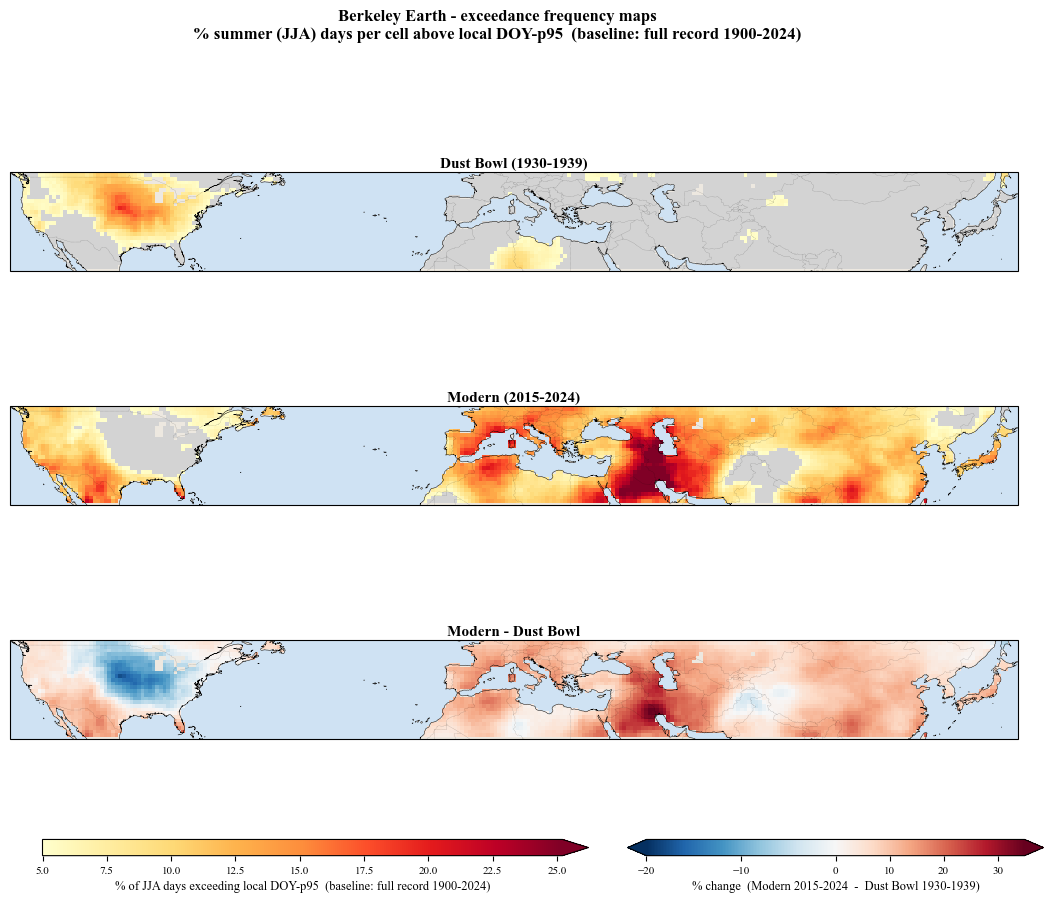

In [36]:
# ─── plot ─────────────────────────────────────────────────────────────────────
lon2d, lat2d = np.meshgrid(_LONS, _LATS)

valid = np.isfinite(_map_dust) | np.isfinite(_map_mod)
extent = ([lon2d[valid].min() - 2, lon2d[valid].max() + 2,
           lat2d[valid].min() - 1, lat2d[valid].max() + 1]
          if valid.any() else [-180, 180, float(_LATS.min()), float(_LATS.max())])

_vmax = float(np.nanpercentile(
    np.concatenate([_map_dust[np.isfinite(_map_dust)],
                    _map_mod[np.isfinite(_map_mod)]]), 99))

cmap_abs  = plt.cm.YlOrRd.copy()
cmap_abs.set_bad('none')
cmap_abs.set_under('lightgrey')

cmap_diff = plt.cm.RdBu_r.copy()
cmap_diff.set_bad('none')
_norm_diff = TwoSlopeNorm(vmin=_DIFF_VMIN, vcenter=0.0, vmax=_DIFF_VMAX)

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(3, 1, figsize=(13, 9),
                          subplot_kw={'projection': proj},
                          gridspec_kw={'hspace': 0.04})

rows = [
    (_map_dust, cmap_abs,  _CLIM_THRESH, _vmax,      None,       f'Dust Bowl ({_DUST_YRS[0]}-{_DUST_YRS[-1]})'),
    (_map_mod,  cmap_abs,  _CLIM_THRESH, _vmax,      None,       f'Modern ({_MOD_YRS[0]}-{_MOD_YRS[-1]})'),
    (_map_diff, cmap_diff, _DIFF_VMIN,   _DIFF_VMAX, _norm_diff, 'Modern - Dust Bowl'),
]

_pcm_abs = _pcm_diff = None
for ax, (data, cmap, vmin_, vmax_, norm_, title) in zip(axes, rows):
    ax.set_extent(extent, crs=proj)
    ax.add_feature(cfeature.OCEAN.with_scale('50m'),     facecolor='#cfe2f3', zorder=0)
    ax.add_feature(cfeature.LAND.with_scale('50m'),      facecolor='#ede8e0', zorder=0)
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'),  linewidth=0.35,      zorder=2)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'),   linewidth=0.15, ls=':', zorder=2)
    if norm_ is not None:
        pcm = ax.pcolormesh(lon2d, lat2d, data, cmap=cmap,
                             norm=norm_, transform=proj,
                             zorder=1, shading='auto')
    else:
        pcm = ax.pcolormesh(lon2d, lat2d, data, cmap=cmap,
                             vmin=vmin_, vmax=vmax_, transform=proj,
                             zorder=1, shading='auto')
    ax.set_title(title, fontsize=11, fontweight='bold', fontfamily='serif', pad=3)
    if cmap is cmap_abs:
        _pcm_abs = pcm
    else:
        _pcm_diff = pcm
    ax.set_xticks([]); ax.set_yticks([])

ax_cb_abs  = fig.add_axes([0.15, 0.05, 0.42, 0.018])
ax_cb_diff = fig.add_axes([0.60, 0.05, 0.32, 0.018])

cb_a = fig.colorbar(_pcm_abs,  cax=ax_cb_abs,  orientation='horizontal', extend='max')
cb_a.set_label(
    f'% of JJA days exceeding local DOY-p95  (baseline: full record {_BASE_S}-{_BASE_E})',
    fontsize=9)
cb_a.ax.tick_params(labelsize=8)

cb_d = fig.colorbar(_pcm_diff, cax=ax_cb_diff, orientation='horizontal', extend='both')
cb_d.set_label(
    f'% change  (Modern {_MOD_YRS[0]}-{_MOD_YRS[-1]}  -  Dust Bowl {_DUST_YRS[0]}-{_DUST_YRS[-1]})',
    fontsize=9)
cb_d.ax.tick_params(labelsize=8)

fig.suptitle(
    f'Berkeley Earth - exceedance frequency maps\n'
    f'% summer (JJA) days per cell above local DOY-p95  '
    f'(baseline: full record {_BASE_S}-{_BASE_E})',
    fontsize=12, fontweight='bold', fontfamily='serif', y=0.99,
)

out = FIGD / (f'Fig_spatial_BE_dustbowl_vs_modern_JJA_grey5pct_'
                 f'{_MOD_YRS[0]}_{_MOD_YRS[-1]}_fixeddiff_FULLRECORDp95.png')
fig.savefig(out, bbox_inches='tight', dpi=150)
plt.show()
plt.close()


## 9. Figure 5 — the northern mid-latitude band

JJA anomalies over 24-50N, with CONUS thinned to match the rest of the band's sampling.


In [37]:

warnings.filterwarnings("ignore", category=RuntimeWarning)
for _d in (FIGD, CACHE_BAND): _d.mkdir(parents=True, exist_ok=True)

# -- Settings ---------------------------------------------------------------
Y0_F5, Y1_F5        = 1900, 2024
JJA           = [6, 7, 8]
BAND_LAT      = (24.0, 50.0)
GRID_DEG      = 2.0                 # analysis grid for the co-sample
MIN_JJA_DAYS  = 75                  # of 92; a cell/station needs this many
MIN_BASE_YRS  = 15                  # of 30, per station and per cell
TMAX_BOUNDS_F5   = (-60.0, 60.0)
N_DRAWS       = 20                  # random co-sample realizations per year
RNG_SEED      = 42
SMOOTH        = 11                  # ODD, so the centred window is symmetric
TRIM_TERMINAL = False               # see note 7; reports either way
MAD_K         = 8.0
DUSTBOWL      = (1930, 1940)
SHOW_ANNUAL_F5   = False               # v9b: panels show smoothed curves only
YPAD_FRAC     = 0.08                # padding as a fraction of the drawn range
FORCE_F5         = False
COL_GH_F5, COL_BE_F5 = "#E63946", "#009E73"
TAG_F5 = f"{int(GRID_DEG*10)}deg_d{MIN_JJA_DAYS}_b{MIN_BASE_YRS}"

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 16, "axes.titlesize": 20, "axes.labelsize": 16,
    "xtick.labelsize": 14, "ytick.labelsize": 14, "legend.fontsize": 14,
    "axes.spines.top": False, "axes.spines.right": False, "axes.linewidth": 0.8,
    "xtick.direction": "out", "ytick.direction": "out",
    "xtick.major.size": 3.5, "ytick.major.size": 3.5, "savefig.dpi": 300,
})

YEARS_F5 = np.arange(Y0_F5, Y1_F5 + 1)
LAT_EDGES = np.arange(BAND_LAT[0], BAND_LAT[1] + 1e-9, GRID_DEG)
LON_EDGES = np.arange(-180.0, 180.0 + 1e-9, GRID_DEG)
LATC = 0.5 * (LAT_EDGES[:-1] + LAT_EDGES[1:])
LONC = 0.5 * (LON_EDGES[:-1] + LON_EDGES[1:])
NLAT, NLON = LATC.size, LONC.size
CELLW = np.repeat(np.cos(np.deg2rad(LATC))[:, None], NLON, axis=1)   # cos(lat)

def conus_cell_mask():
    """True where a cell's centre is inside CONUS. Cached."""
    fp = CACHE_BAND / f"conus_cells_{TAG_F5}.npy"
    if fp.exists():
        return np.load(fp)
    poly = conus_polygon()
    LON2, LAT2 = np.meshgrid(LONC, LATC)
    try:
        import shapely
        m = np.asarray(shapely.contains_xy(poly, LON2.ravel(), LAT2.ravel()))
    except Exception:
        from shapely.geometry import Point
        from shapely.prepared import prep
        pp = prep(poly)
        m = np.array([pp.contains(Point(o, a))
                      for a, o in zip(LAT2.ravel(), LON2.ravel())])
    m = m.reshape(LAT2.shape)
    np.save(fp, m)
    return m

CONUS = conus_cell_mask()

# ══ (1) GHCN-DAILY FROM THE STATION ARCHIVE ════════════════════════════════
STN_FP = CACHE_BAND / f"ghcn_band_station_jja_{Y0_F5}_{Y1_F5}.parquet"

def build_station_jja():
    """Per station and year: JJA mean TMAX and TMIN, from the global parquets.
    A station-year is kept only if BOTH elements have >= MIN_JJA_DAYS days, so
    TAVG is formed from the same days as TMAX and TMIN."""
    if STN_FP.exists() and not FORCE_F5:
        return pd.read_parquet(STN_FP)
    qcols = None
    parts = []
    for y in range(Y0_F5, Y1_F5 + 1):
        fp = GHCND_GLOBAL / f"ghcn_global_{y}.parquet"
        if not fp.exists():
            continue
        if qcols is None:
            avail = set(pd.read_parquet(fp).head(0).columns)
            qcols = [c for c in ("qflag", "q_flag", "quality_flag") if c in avail]
        d = pd.read_parquet(fp, columns=["station_id", "date", "tmax_c", "tmin_c",
                                         "lat", "lon"] + qcols)
        d = d[d["lat"].between(*BAND_LAT)]
        if d.empty:
            continue
        for c in qcols:
            d = d[d[c].fillna("").astype(str).str.strip() == ""]
        dt = pd.DatetimeIndex(d["date"])
        d = d[np.isin(dt.month, JJA)]
        if d.empty:
            continue
        for c in ("tmax_c", "tmin_c"):
            d.loc[~d[c].between(*TMAX_BOUNDS_F5), c] = np.nan
        d = d.drop_duplicates(subset=["station_id", "date"], keep="first")
        g = d.groupby("station_id").agg(
            tmax=("tmax_c", "mean"), n_tmax=("tmax_c", "count"),
            tmin=("tmin_c", "mean"), n_tmin=("tmin_c", "count"),
            lat=("lat", "first"), lon=("lon", "first")).reset_index()
        g = g[(g["n_tmax"] >= MIN_JJA_DAYS) & (g["n_tmin"] >= MIN_JJA_DAYS)]
        if g.empty:
            continue
        g["year"] = y
        parts.append(g[["station_id", "year", "lat", "lon", "tmax", "tmin"]])
    out = pd.concat(parts, ignore_index=True)
    out.to_parquet(STN_FP, index=False)
    return out

STN = build_station_jja()

# ══ (2) STATION ANOMALIES, THEN BIN TO THE GRID ════════════════════════════
def station_anomaly_field():
    """(year, lat, lon) GHCN-Daily JJA anomaly, and the count of stations per
    cell. Every station is anomalised against ITS OWN 1951-1980 JJA mean BEFORE
    any spatial averaging, so a changing station set cannot inject climatology."""
    fp = CACHE_BAND / f"ghcn_band_field_{TAG_F5}.npz"
    if fp.exists() and not FORCE_F5:
        z = np.load(fp)
        return z["tmax"], z["tmin"], z["n"]
    d = STN.copy()
    base = d[d["year"].between(*BASELINE)]
    clim = base.groupby("station_id").agg(
        cx=("tmax", "mean"), cn=("tmin", "mean"), k=("year", "count"))
    clim = clim[clim["k"] >= MIN_BASE_YRS]
    d = d.join(clim, on="station_id", how="inner")
    d["ax"] = d["tmax"] - d["cx"]
    d["an"] = d["tmin"] - d["cn"]
    d["il"] = np.clip(((d["lat"] - LAT_EDGES[0]) / GRID_DEG).astype(int), 0, NLAT - 1)
    d["io"] = np.clip(((d["lon"] + 180.0) / GRID_DEG).astype(int), 0, NLON - 1)
    d["yi"] = d["year"] - Y0_F5
    tx = np.full((len(YEARS_F5), NLAT, NLON), np.nan, np.float32)
    tn = np.full((len(YEARS_F5), NLAT, NLON), np.nan, np.float32)
    nn = np.zeros((len(YEARS_F5), NLAT, NLON), np.int16)
    g = d.groupby(["yi", "il", "io"]).agg(ax=("ax", "mean"), an=("an", "mean"),
                                          n=("ax", "size")).reset_index()
    tx[g["yi"], g["il"], g["io"]] = g["ax"].to_numpy(np.float32)
    tn[g["yi"], g["il"], g["io"]] = g["an"].to_numpy(np.float32)
    nn[g["yi"], g["il"], g["io"]] = g["n"].to_numpy(np.int16)
    np.savez_compressed(fp, tmax=tx, tmin=tn, n=nn)
    return tx, tn, nn

GH_TX, GH_TN, GH_N = station_anomaly_field()

# ══ (4) BERKELEY: CELL ANOMALIES, AGGREGATED ONTO THE SAME GRID ════════════
def berkeley_band_field():
    """(year, lat, lon) Berkeley JJA anomaly on the analysis grid. Each 1-degree
    cell is anomalised against its own 1951-1980 JJA mean, then the analysis
    cell takes the cos(lat)-weighted mean of the 1-degree cells inside it."""
    fp = CACHE_BAND / f"berkeley_band_field_{TAG_F5}.npz"
    if fp.exists() and not FORCE_F5:
        z = np.load(fp)
        return z["tmax"], z["tmin"]
    out = {}
    for var in ("TMAX", "TMIN"):
        ann, blat, blon = None, None, None
        for dec in range(1900, 2030, 10):
            f = BE_PROC / f"processed_nh_{var}_Complete_{var}_Daily_LatLong1_{dec}.nc"
            if not f.exists():
                continue
            ds = xr.open_dataset(f)
            t = ds["temperature"]
            la = ds["latitude"].values.astype(float)
            lo = ds["longitude"].values.astype(float)
            if lo.max() > 180.0:
                lo = np.where(lo > 180.0, lo - 360.0, lo)
            keep_la = (la >= BAND_LAT[0]) & (la <= BAND_LAT[1])   # direction-safe
            tt = pd.DatetimeIndex(t["time"].values)
            sel = np.isin(tt.month, JJA)
            v = t.values[sel][:, keep_la, :].astype(np.float32)
            v = np.where(np.isfinite(v) & (np.abs(v) < 1e4), v, np.nan)
            yrs = tt.year.values[sel]
            lm = ds["land_mask"]
            lm = (lm.isel(time=0) if "time" in lm.dims else lm).values[keep_la, :]
            ds.close()
            if ann is None:
                blat, blon = la[keep_la], lo
                ann = np.full((len(YEARS_F5), blat.size, blon.size), np.nan, np.float32)
                land = lm > 0
            for y in np.unique(yrs):
                if not (Y0_F5 <= y <= Y1_F5):
                    continue
                k = yrs == y
                if k.sum() < MIN_JJA_DAYS:
                    continue
                m = np.nanmean(v[k], axis=0)
                cnt = np.isfinite(v[k]).sum(axis=0)
                ann[y - Y0_F5] = np.where(cnt >= MIN_JJA_DAYS, m, np.nan)
        ann = np.where(land[None, :, :], ann, np.nan)
        b = (YEARS_F5 >= BASELINE[0]) & (YEARS_F5 <= BASELINE[1])
        nb = np.isfinite(ann[b]).sum(axis=0)
        clim = np.where(nb >= MIN_BASE_YRS, np.nanmean(ann[b], axis=0), np.nan)
        anom = ann - clim[None, :, :]
        # aggregate 1 deg -> analysis grid, cos(lat) weighted
        il = np.clip(((blat - LAT_EDGES[0]) / GRID_DEG).astype(int), 0, NLAT - 1)
        io = np.clip(((blon + 180.0) / GRID_DEG).astype(int), 0, NLON - 1)
        w1 = np.cos(np.deg2rad(blat))[:, None] * np.ones(blon.size)[None, :]
        num = np.zeros((len(YEARS_F5), NLAT, NLON)); den = np.zeros_like(num)
        good = np.isfinite(anom)
        aw = np.where(good, anom * w1[None, :, :], 0.0)
        ww = np.where(good, w1[None, :, :], 0.0)
        for i in range(blat.size):
            np.add.at(num, (slice(None), il[i], io), aw[:, i, :])
            np.add.at(den, (slice(None), il[i], io), ww[:, i, :])
        out[var] = np.where(den > 0, num / np.where(den > 0, den, 1), np.nan).astype(np.float32)
    np.savez_compressed(fp, tmax=out["TMAX"], tmin=out["TMIN"])
    return out["TMAX"], out["TMIN"]

BE_TX, BE_TN = berkeley_band_field()

# ══ (3)(7) THE CO-SAMPLE: identical cells for both datasets, N_DRAWS times ══
rng = np.random.default_rng(RNG_SEED)
res = {k: np.full((N_DRAWS, len(YEARS_F5)), np.nan)
       for k in ("gh_tx", "gh_tn", "be_tx", "be_tn")}
full = {k: np.full(len(YEARS_F5), np.nan) for k in ("gh_tx", "gh_tn", "be_tx", "be_tn")}
diag = []
for yi, y in enumerate(YEARS_F5):
    # a cell counts only if BOTH datasets have it -- this is what makes it a
    # co-sample, and what v8j silently violated
    ok = (np.isfinite(GH_TX[yi]) & np.isfinite(GH_TN[yi])
          & np.isfinite(BE_TX[yi]) & np.isfinite(BE_TN[yi]))
    c_idx = np.argwhere(ok & CONUS)
    r_idx = np.argwhere(ok & ~CONUS)
    if len(c_idx) == 0 or len(r_idx) == 0:
        continue
    # unsampled full-band reference, for context
    fi = np.argwhere(ok)
    fw = CELLW[fi[:, 0], fi[:, 1]]
    for k, F in (("gh_tx", GH_TX), ("gh_tn", GH_TN), ("be_tx", BE_TX), ("be_tn", BE_TN)):
        full[k][yi] = np.sum(F[yi][fi[:, 0], fi[:, 1]] * fw) / np.sum(fw)
    n_draw = min(len(r_idx), len(c_idx))
    for dch in range(N_DRAWS):
        cs = c_idx[rng.choice(len(c_idx), size=n_draw, replace=False)] \
             if n_draw < len(c_idx) else c_idx
        sel = np.concatenate([cs, r_idx], axis=0)
        w = CELLW[sel[:, 0], sel[:, 1]]
        for k, F in (("gh_tx", GH_TX), ("gh_tn", GH_TN),
                     ("be_tx", BE_TX), ("be_tn", BE_TN)):
            res[k][dch, yi] = np.sum(F[yi][sel[:, 0], sel[:, 1]] * w) / np.sum(w)
    diag.append((y, len(c_idx), len(r_idx), n_draw))


In [38]:
# ══ SERIES, LIGHT FILTERING, DIAGNOSTICS ═══════════════════════════════════
def mad_flag(v, k=MAD_K):
    v = np.asarray(v, float)
    med = np.nanmedian(v); mad = np.nanmedian(np.abs(v - med))
    if not np.isfinite(mad) or mad == 0:
        return np.zeros(v.shape, bool)
    return np.isfinite(v) & (np.abs(v - med) > k * 1.4826 * mad)

def finish(mat, label):
    """Ensemble mean over draws, one MAD pass (not two), terminal trim reported."""
    m = np.nanmean(mat, axis=0) if mat.ndim == 2 else np.asarray(mat, float)
    bad = mad_flag(m)
    if bad.any():
        m = np.where(bad, np.nan, m)
    fi = np.where(np.isfinite(m))[0]
    if len(fi) >= 15:
        hist, tail = fi[:-2], fi[-2:]
        med = np.nanmedian(m[hist]); mad = np.nanmedian(np.abs(m[hist] - med))
        if np.isfinite(mad) and mad > 0:
            drop = [i for i in tail if abs(m[i] - med) > 6.0 * 1.4826 * mad]
            if drop:
                if TRIM_TERMINAL:
                    m[drop] = np.nan
    return pd.Series(m, index=YEARS_F5)

S   = {k: finish(res[k], k) for k in res}
SF  = {k: finish(full[k], f"{k} (full band)") for k in full}
SPR = {k: pd.DataFrame(res[k], columns=YEARS_F5) for k in res}
S["gh_ta"] = 0.5 * (S["gh_tx"] + S["gh_tn"])
S["be_ta"] = 0.5 * (S["be_tx"] + S["be_tn"])
SF["gh_ta"] = 0.5 * (SF["gh_tx"] + SF["gh_tn"])
SF["be_ta"] = 0.5 * (SF["be_tx"] + SF["be_tn"])
for k in ("gh_ta", "be_ta"):
    SPR[k] = 0.5 * (SPR[k.replace("_ta", "_tx")] + SPR[k.replace("_ta", "_tn")])

smooth = lambda s: s.rolling(SMOOTH, center=True, min_periods=SMOOTH).mean()


In [39]:
# CHECK -- Figure 5 series, before plotting. JJA anomaly on the 24-50N band.
print(f"{'series':<28}{'1930s':>8}{'2010-24':>9}{'trend/century':>15}{'years':>7}")
for _lbl, _k in (("GHCN-Daily TMAX", "gh_tx"), ("GHCN-Daily TMIN", "gh_tn"),
                 ("Berkeley TMAX", "be_tx"), ("Berkeley TMIN", "be_tn")):
    _s = S[_k].dropna()
    _tr = np.polyfit(_s.index, _s.values, 1)[0] * 100
    print(f"  {_lbl:<26}{_s.loc[1930:1939].mean():>+8.2f}{_s.loc[2010:2024].mean():>+9.2f}"
          f"{_tr:>+15.2f}{len(_s):>7}")
print(f"\nequal-region sampling: {N_DRAWS} draws, spread (1 s.d. across draws) "
      f"{float(np.nanmean(np.nanstd(res['gh_tx'], axis=0))):.3f} degC")


series                         1930s  2010-24  trend/century  years
  GHCN-Daily TMAX              +0.62    +1.11          +0.81    125
  GHCN-Daily TMIN              +0.28    +1.39          +1.31    125
  Berkeley TMAX                +0.57    +1.23          +0.95    125
  Berkeley TMIN                +0.10    +1.27          +1.44    125

equal-region sampling: 20 draws, spread (1 s.d. across draws) 0.008 degC


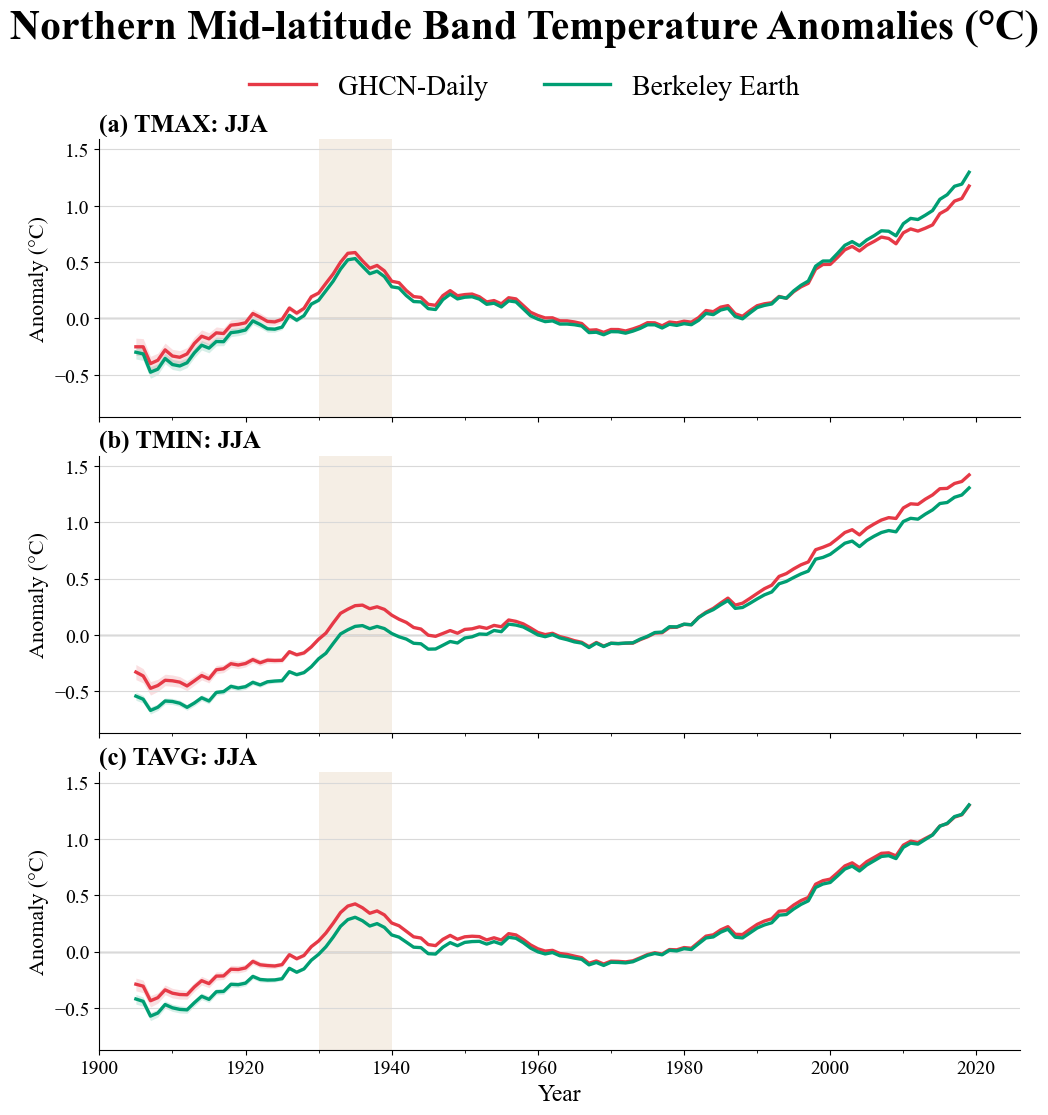

In [40]:
# ══ PLOT — smoothed curves only, scaled to what is actually drawn ══════════
PANELS = [("(a) TMAX: JJA", "gh_tx", "be_tx"),
          ("(b) TMIN: JJA", "gh_tn", "be_tn"),
          ("(c) TAVG: JJA", "gh_ta", "be_ta")]

# precompute everything that will appear on the axes, and scale to THAT
SM   = {k: smooth(S[k]) for _, a, b in PANELS for k in (a, b)}
BAND = {k: (smooth(SPR[k].quantile(0.025)), smooth(SPR[k].quantile(0.975)))
        for _, a, b in PANELS for k in (a, b)}
_drawn = np.concatenate(
    [v.to_numpy(float) for v in SM.values()]
    + [x.to_numpy(float) for lo_hi in BAND.values() for x in lo_hi])
_drawn = _drawn[np.isfinite(_drawn)]
_pad = YPAD_FRAC * (np.nanmax(_drawn) - np.nanmin(_drawn))
_lo, _hi = np.nanmin(_drawn) - _pad, np.nanmax(_drawn) + _pad

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True, constrained_layout=True)
for ax, (title, kg, kb) in zip(axes, PANELS):
    ax.axvspan(*DUSTBOWL, color="#caa472", alpha=0.18, lw=0, zorder=0)
    for lbl, k, col in (("GHCN-Daily", kg, COL_GH_F5), ("Berkeley Earth", kb, COL_BE_F5)):
        lo, hi = BAND[k]
        ax.fill_between(YEARS_F5, lo.values, hi.values, color=col, alpha=0.16, lw=0,
                        zorder=1)               # spread across the random draws
        if SHOW_ANNUAL_F5:
            ax.plot(YEARS_F5, S[k].values, color=col, lw=0.9, alpha=0.28, zorder=2)
        ax.plot(YEARS_F5, SM[k].values, color=col, lw=2.4, label=lbl, zorder=3)
    ax.axhline(0, color="0.2", lw=0.9, alpha=0.8, zorder=0)
    ax.set_title(title, loc="left", fontweight="bold", fontsize=18)
    ax.set_ylabel("Anomaly (°C)")
    ax.grid(True, axis="y", color="0.85", lw=0.8); ax.grid(False, axis="x")
    ax.set_ylim(_lo, _hi); ax.set_xlim(1900, 2026)
    ax.tick_params(axis="both", labelsize=14)
axes[2].set_xlabel("Year", fontsize=17)
axes[2].xaxis.set_major_locator(mticker.MultipleLocator(20))
axes[2].xaxis.set_minor_locator(mticker.MultipleLocator(10))

h, l, seen = [], [], set()
for ax in axes:
    for hh, ll in zip(*ax.get_legend_handles_labels()):
        if ll not in seen:
            h.append(hh); l.append(ll); seen.add(ll)
fig.legend(h, l, loc="upper center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.06), handlelength=2.4, columnspacing=2, fontsize=20)
fig.suptitle("Northern Mid-latitude Band Temperature Anomalies (°C)",
             fontsize=30, fontweight="bold", color="black", y=1.10)
OUT_F5 = FIGD / f"FigG_v9b_band_jja_smoothed_{TAG_F5}.png"
fig.savefig(OUT_F5, bbox_inches="tight", dpi=300, facecolor="white")
fig.savefig(OUT_F5.with_suffix(".pdf"), bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)


## 10. Figure 6 — heat-wave days

Runs of six or more days above a cell's own day-of-season 90th percentile, CONUS against the global 24-50N strip. Needs the daily station cube built in section 7.


In [41]:

warnings.filterwarnings("ignore", category=RuntimeWarning)
CACHE_HW.mkdir(exist_ok=True)
F3_TAG       = "y100_f0.8_b-40-57"
F3_DAILY_FP  = CACHE_REC / f"ghcnd_daily_mjjas_conus_{F3_TAG}.npz"

UH_YR0, UH_YR1 = 1900, 2024
UH_LAT_BNDS, UH_LON_BNDS = (24.0, 50.0), (-130.0, -60.0)
USHCN_LEGS = ("raw", "adj")

GHCND_CONUS_SOURCE = "stations"   # "stations" (fixed) | "christy_grid" (old)
COMPARE_BOTH_GHCND = False
BLANK_BE_PARTIAL   = True
MIN_THRESH_N       = 30
SMOOTH_W           = 5
USREG_MODE         = "polygon"

# (A) which rows draw GHCN-Daily as uncorrected (dot-dashed).
#     (0, 1) = both rows, one style per dataset;  (0,) = top row only, literally
#     what the advisor asked for.
GHCND_UNCORR_ROWS = (0, 1)

# (W1)(W5) panel geometry and how the y-axis is scaled.
#   PANEL_W x PANEL_H is the box each subplot gets, in inches. 5.6 x 3.25 is
#   about 1.7:1; v G was effectively 3.9 x 3.4, i.e. square.
#   YLIM_FROM "annual"   -- scale to the annual traces, as v G did
#             "smoothed" -- scale to the smoothed curves, ~35% taller, and hide
#                           the annual traces so that nothing is clipped
PANEL_W, PANEL_H = 5.6, 3.25
YLIM_FROM        = "smoothed"
SHOW_ANNUAL_F6      = (YLIM_FROM == "annual")
LW_SMOOTH, LW_ANNUAL, ALPHA_ANNUAL = 2.5, 0.55, 0.26      # (W2)

# (B) Berkeley re-sampled onto a station network's footprint, Figure 3 style.
#     Each entry is a network whose station positions define the units.
BE_AT_NETWORKS   = ("ushcn",)
DRAW_BE_AT_USHCN = True         # the dashed line in the Berkeley CONUS panel
PLOT_BE_NETWORKS = False         # the extra GHCN-vs-USHCN comparison figure

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix", "font.size": 15, "axes.titlesize": 18,
    "axes.labelsize": 16, "xtick.labelsize": 14, "ytick.labelsize": 14,
    "legend.fontsize": 14, "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 1.1, "xtick.direction": "out", "ytick.direction": "out",
    "xtick.major.size": 5, "ytick.major.size": 5,
    "xtick.major.width": 1.1, "ytick.major.width": 1.1,
})
FS_COLTITLE, FS_YLABEL, FS_XLABEL = 19, 16, 16
FS_TICK, FS_EMPTY, FS_PANLEG = 14, 15, 13.5
C = {"Berkeley": "#009E73", "GHCND": "#E63946", "ERA5": "#F59E0B",
     "USHCN": "#6D28D9"}
# (W3) the re-sampled Berkeley line is a DARKER GREEN, not the same green. Two
# 2.5 pt lines in one colour merge into a single blob wherever they cross, which
# is most of the record; same hue keeps it reading as Berkeley, the darker value
# keeps it readable as a separate line.
C_SAMPLED = "#00513C"
# (A) one style vocabulary for the whole figure:
#   solid     homogenised / bias-corrected / reanalysis
#   dot-dash  UNCORRECTED station data (GHCN-Daily, USHCN-Daily raw)
#   dashed    a corrected product re-sampled onto another network's footprint
# (W3) spelled-out dash patterns: at this panel width a default "-." and "--"
# are easy to confuse, and telling them apart is the whole point of the figure.
LS_ADJ     = "-"
LS_UNCORR  = (0, (6.5, 1.8, 1.0, 1.8))     # long dash, dot -- uncorrected
LS_SAMPLED = (0, (7.0, 2.4))               # long open dash -- re-sampled
LS_RAW = LS_UNCORR                      # v F name kept so nothing downstream breaks

_PCTILE, _WINDOW, _MIN_RUN, _MIN_FRAC = 90, 3, 6, 0.70
_HW_MON, _N_DOY = {5, 6, 7, 8, 9}, 153

def mask_conus(lat, lon, key):
    fp = CACHE_HW / f"maskconus_{key}.npy"
    if fp.exists(): return np.load(fp)
    m = points_in_grid(conus_polygon(), lat, lon); np.save(fp, m); return m

def mask_land(lat, lon, key):
    fp = CACHE_HW / f"maskland_{key}.npy"
    if fp.exists(): return np.load(fp)
    m = points_in_grid(land_polygon(), lat, lon); np.save(fp, m); return m

def _jaccard(a, b):
    u = int((a | b).sum())
    return float((a & b).sum() / u) if u else 0.0

# ══ CORE ALGORITHM ═════════════════════════════════════════════════════════
def _season_doy(times):
    """Day of the May-September season, 1..153."""
    ts = pd.DatetimeIndex(times)
    return (ts.dayofyear.to_numpy() - np.where(ts.is_leap_year, 121, 120)).astype(np.int16)

def _thresholds(tx_s, doys):
    T, nlat, nlon = tx_s.shape
    thr = np.full((_N_DOY, nlat, nlon), np.nan, dtype=np.float32)
    doys = np.asarray(doys, np.int16)
    for doy in range(1, _N_DOY + 1):
        m = np.abs(doys - doy) <= _WINDOW
        vals = tx_s[m]
        if vals.shape[0] == 0:
            continue
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            p = np.nanpercentile(vals, _PCTILE, axis=0)
        n = np.isfinite(vals).sum(axis=0)          # (7)
        thr[doy - 1] = np.where(n >= MIN_THRESH_N, p, np.nan)
    return thr

def _count_hw(exceed):
    T = exceed.shape[0]
    exc = exceed.astype(np.int16)
    rl = np.zeros_like(exc); rl[0] = exc[0]
    for t in range(1, T):
        rl[t] = np.where(exc[t], rl[t - 1] + 1, 0)
    rt = rl.copy()
    for t in range(T - 2, -1, -1):
        same = (exc[t] == 1) & (rl[t + 1] == rl[t] + 1)
        rt[t] = np.where(same, rt[t + 1], rt[t])
    return np.sum(exceed & (rt >= _MIN_RUN), axis=0).astype(np.float32)

def _assert_contiguous(dy, yr, label):
    """(8) runs are only meaningful if a year's days are ordered and unbroken."""
    for y in np.unique(yr):
        d = dy[yr == y]
        if d.size < 2:
            continue
        if not np.all(np.diff(d) == 1):
            gaps = int((np.diff(d) != 1).sum())
            raise ValueError(f"{label}: year {y} has {gaps} break(s) in its "
                             f"day-of-season axis. Runs would be fused across the "
                             f"gap. Reindex the time axis to the full MJJAS calendar.")

def christy_fields(tx_s, doys, yrs, label=""):
    """(C) {year: HW-days grid}. Thresholds and run counting only -- no spatial
    reduction, so one pass over a dataset can serve several domains/footprints."""
    doys = np.asarray(doys, np.int16); yrs = np.asarray(yrs, int)
    _assert_contiguous(doys, yrs, label)
    thr = _thresholds(tx_s, doys)
    fields = {}
    for yr in np.unique(yrs):
        m = yrs == yr; tx = tx_s[m]; dy = doys[m]
        vf = np.sum(~np.isnan(tx), axis=0) / _N_DOY
        exc = (~np.isnan(tx)) & np.isfinite(thr[dy - 1]) & (tx > thr[dy - 1])
        hw = _count_hw(exc)
        hw[vf < _MIN_FRAC] = np.nan
        fields[int(yr)] = hw
    return fields

def _reduce_fields(fields, lat, lon, mask=None,
                   lat_bnds=(24., 50.), lon_bnds=(-180., 180.), label=""):
    """(C) cos(lat)-weighted spatial mean of the per-cell HW fields."""
    lat = np.asarray(lat, float); lon = np.asarray(lon, float)
    lat_ok = (lat >= lat_bnds[0]) & (lat <= lat_bnds[1])
    lo360, hi360 = lon_bnds[0] % 360, lon_bnds[1] % 360
    lon360 = lon % 360
    lon_ok = ((lon360 >= lo360) & (lon360 <= hi360)
              if hi360 > lo360 else (lon360 >= lo360) | (lon360 <= hi360))
    dom = lat_ok[:, None] & lon_ok[None, :]
    if mask is not None:
        mask = np.asarray(mask, bool)
        assert mask.shape == dom.shape, \
            f"{label}: mask {mask.shape} does not match grid {dom.shape}"
        dom = dom & mask
    cosw = np.cos(np.radians(lat))[:, None] * np.ones(len(lon))
    series = {}
    for yr in sorted(fields):
        valid = dom & ~np.isnan(fields[yr])
        if not np.any(valid): continue
        w = cosw[valid]
        series[int(yr)] = float(np.nansum(fields[yr][valid] * w) / np.nansum(w))
    return series

def christy_series(tx_s, doys, yrs, lat, lon, mask=None,
                   lat_bnds=(24., 50.), lon_bnds=(-180., 180.), label=""):
    """v F signature, now a thin wrapper over christy_fields + _reduce_fields."""
    return _reduce_fields(christy_fields(tx_s, doys, yrs, label=label),
                          lat, lon, mask=mask,
                          lat_bnds=lat_bnds, lon_bnds=lon_bnds, label=label)

def christy_series_stations(tx_s, doys, yrs, stn_lats, label=""):
    doys = np.asarray(doys, np.int16); yrs = np.asarray(yrs, int)
    _assert_contiguous(doys, yrs, label)
    tx3 = tx_s[:, np.newaxis, :]
    thr = _thresholds(tx3, doys)
    cosw = np.cos(np.radians(stn_lats))
    series = {}
    for yr in np.unique(yrs):
        m = yrs == yr; tx = tx3[m]; dy = doys[m]
        vf = np.sum(~np.isnan(tx), axis=0)[0] / _N_DOY
        exc = (~np.isnan(tx)) & np.isfinite(thr[dy - 1]) & (tx > thr[dy - 1])
        hw = _count_hw(exc)[0]
        hw[vf < _MIN_FRAC] = np.nan
        valid = ~np.isnan(hw)
        if not np.any(valid): continue
        w = cosw[valid]
        series[int(yr)] = float(np.nansum(hw[valid] * w) / np.nansum(w))
    return series

def _reindex_full(vals, times, label):
    """Force the array onto the complete MJJAS calendar, so no missing row can
    fuse two runs. Returns (vals, doys, yrs)."""
    times = pd.DatetimeIndex(times)
    y0, y1 = int(times.year.min()), int(times.year.max())
    full = pd.date_range(f"{y0}-01-01", f"{y1}-12-31", freq="D")
    full = full[np.isin(full.month, list(_HW_MON))]
    if len(times) != len(full) or not (times == full).all():
        pos = pd.Index(full).get_indexer(times)
        out = np.full((len(full),) + vals.shape[1:], np.nan, np.float32)
        g = pos >= 0
        out[pos[g]] = vals[g]
        vals = out
    return vals, _season_doy(full), full.year.values.astype(int)

# ══ CONUS LOADERS ══════════════════════════════════════════════════════════
def ld_be_conus():
    fp = ROOT / "Berkeley_Earth/Processed/preprocessed_us_TMAX_data.nc"
    ds = xr.open_dataset(fp)
    lat, lon = ds.latitude.values, ds.longitude.values
    lm = ds["land_mask"]
    lm = (lm.isel(time=0) if "time" in lm.dims else lm).values >= 0.5
    times = pd.DatetimeIndex(ds.time.values)
    sm = np.isin(times.month, list(_HW_MON))
    tx = ds["temperature"].values[sm].astype(np.float32)
    ds.close()
    tx, dy, yr = _reindex_full(tx, times[sm], "BE US")
    return tx, dy, yr, lat, lon, lm & mask_conus(lat, lon, "be_us")

def _resolve_conus_grid_mask(lat, lon):
    """(5) usreg_half.txt is checked for orientation, not trusted."""
    poly = mask_conus(lat, lon, "ghcnd_idw")
    if not USREG_FP.exists():
        return poly

    U = np.loadtxt(USREG_FP, dtype=int) > 0
    if U.shape != (len(lat), len(lon)):
        return poly

    opts = {"as-is": U, "lat flipped": U[::-1, :],
            "lon flipped": U[:, ::-1], "both flipped": U[::-1, ::-1]}
    scores = {k: _jaccard(v, poly) for k, v in opts.items()}
    best = max(scores, key=scores.get)

    m = {"polygon": poly, "auto": opts[best], "usreg": U}[USREG_MODE]
    return m

def ld_ghcnd_conus_grid():
    dirp = ROOT / "GHCND/Global_Gridded_Christy_IDW"
    files = sorted(dirp.glob("ghcn_grid_????.nc"))
    ds = xr.open_mfdataset(files, combine="by_coords")
    lat, lon = ds.lat.values, ds.lon.values
    times = pd.DatetimeIndex(ds.time.values)
    sm = np.isin(times.month, list(_HW_MON))
    tx = ds["tmax_c"].values[sm].astype(np.float32)
    ds.close()
    m = _resolve_conus_grid_mask(lat, lon)
    tx, dy, yr = _reindex_full(tx, times[sm], "GHCND IDW")
    return tx, dy, yr, lat, lon, m

def ld_ghcnd_conus_stations():
    """(1) GHCN-Daily at stations, from the Figure 3 daily cube."""
    if not F3_DAILY_FP.exists():
        raise FileNotFoundError(
            f"{F3_DAILY_FP} not found. Run the Figure 3 cell that builds the CONUS "
            f"daily station cube first -- it is the same months and years.")
    z = np.load(F3_DAILY_FP, allow_pickle=False)
    ids, V = z["ids"], z["values"].astype(np.float32)
    inv = pd.read_fwf(str(GHCND_INV),
                      colspecs=[(0, 11), (12, 20), (21, 30), (31, 35), (36, 40), (41, 45)],
                      names=["id", "lat", "lon", "elem", "y0", "y1"])
    pos = inv[inv["elem"] == "TMAX"].groupby("id")[["lat", "lon"]].first()
    pos = pos.reindex(pd.Index(ids))
    assert pos["lat"].notna().all(), "some station ids are missing from the inventory"
    full = pd.date_range(f"{UH_YR0}-01-01", f"{UH_YR1}-12-31", freq="D")
    full = full[np.isin(full.month, list(_HW_MON))]
    assert V.shape[0] == len(full), \
        f"cube has {V.shape[0]} rows, the MJJAS calendar has {len(full)}"
    return V, _season_doy(full), full.year.values.astype(int), pos["lat"].values.astype(np.float32)

def ld_era5_conus():
    files = [ROOT / "ERA5" / f"era5_2t_{y:04d}{m:02d}_daily.nc"
             for y in range(1940, 2025) for m in sorted(_HW_MON)
             if (ROOT / "ERA5" / f"era5_2t_{y:04d}{m:02d}_daily.nc").exists()]
    ds = xr.open_mfdataset(sorted(files), combine="by_coords")
    lat_all = ds.latitude.values; lon_all = ds.longitude.values
    lat_ok = (lat_all >= 23) & (lat_all <= 51)             # (8) subset first
    lon180 = np.where(lon_all > 180, lon_all - 360, lon_all)
    lon_ok = (lon180 >= -126) & (lon180 <= -65)
    assert lat_ok.any() and lon_ok.any(), \
        f"ERA5 CONUS box selected nothing; lat {lat_all.min():.1f}..{lat_all.max():.1f}, " \
        f"lon {lon_all.min():.1f}..{lon_all.max():.1f}"
    sub = ds.isel(latitude=np.where(lat_ok)[0], longitude=np.where(lon_ok)[0])
    lat, lon = sub.latitude.values, sub.longitude.values
    tx = (sub["t2m_max"].values - 273.15).astype(np.float32)
    times = pd.DatetimeIndex(sub.time.values)
    ds.close()
    tx, dy, yr = _reindex_full(tx, times, "ERA5 CONUS")
    m = mask_conus(lat, lon, "era5_conus")                 # (2)
    return tx, dy, yr, lat, lon, m

# ══ GLOBAL LOADERS ═════════════════════════════════════════════════════════
def ld_be_global():
    files = sorted((ROOT / "Berkeley_Earth/Processed").glob(
        "processed_nh_TMAX_Complete_TMAX_Daily_LatLong1_????.nc"))
    ds = xr.open_mfdataset(files, combine="by_coords")
    lat_all = ds.latitude.values
    keep = (lat_all >= 23) & (lat_all <= 51)                # (8) subset first
    sub = ds.isel(latitude=np.where(keep)[0])
    lat, lon = sub.latitude.values, sub.longitude.values
    times = pd.DatetimeIndex(sub.time.values)
    _, uniq = np.unique(times.values, return_index=True)    # dedup decades
    sm = np.isin(times.month, list(_HW_MON))
    sm = sm & np.isin(np.arange(len(times)), uniq)
    tx = sub["temperature"].values[sm].astype(np.float32)
    lm = sub["land_mask"]
    lm = (lm.isel(time=0) if "time" in lm.dims else lm).values > 0   # (3)
    ds.close()
    tx, dy, yr = _reindex_full(tx, times[sm], "BE NH")
    return tx, dy, yr, lat, lon, lm

def ld_ghcnd_global():
    dirp = ROOT / "GHCND/Global_Gridded"
    files = sorted(dirp.glob("ghcn_grid_????.nc"))
    ds = xr.open_mfdataset(files, combine="by_coords")
    lat_all = ds.lat.values
    keep = (lat_all >= 23) & (lat_all <= 51)
    sub = ds.isel(lat=np.where(keep)[0])
    lat, lon = sub.lat.values, sub.lon.values
    times = pd.DatetimeIndex(sub.time.values)
    sm = np.isin(times.month, list(_HW_MON))
    tx = sub["tmax_c"].values[sm].astype(np.float32)
    ds.close()
    tx, dy, yr = _reindex_full(tx, times[sm], "GHCND 2deg")
    return tx, dy, yr, lat, lon, None            # station-derived: already land

def ld_era5_global():
    files = [ROOT / "ERA5" / f"era5_2t_{y:04d}{m:02d}_daily.nc"
             for y in range(1940, 2025) for m in sorted(_HW_MON)
             if (ROOT / "ERA5" / f"era5_2t_{y:04d}{m:02d}_daily.nc").exists()]
    ds = xr.open_mfdataset(sorted(files), combine="by_coords")
    lat_all = ds.latitude.values
    keep = np.where((lat_all >= 23) & (lat_all <= 51))[0][::4]   # (8)
    sub = ds.isel(latitude=keep, longitude=slice(None, None, 4))
    lat, lon = sub.latitude.values, sub.longitude.values
    tx = (sub["t2m_max"].values - 273.15).astype(np.float32)
    times = pd.DatetimeIndex(sub.time.values)
    ds.close()
    tx, dy, yr = _reindex_full(tx, times, "ERA5 global")
    m = mask_land(lat, lon, "era5_global")       # (2)
    return tx, dy, yr, lat, lon, m


# ══ USHCN PAIR (unchanged: the matched design is right) ════════════════════
def _uh_piv_fp(leg):
    _mtag = "".join(str(m) for m in sorted(_HW_MON))
    return UH_PIV_DIR / f"ushcn_pair_tmax_pivot_m{_mtag}_{leg}.parquet"

def uh_available():
    return (UH_STN_FP.exists()
            and ((_uh_piv_fp("raw").exists() and _uh_piv_fp("adj").exists())
                 or (UH_DAILY_DIR.is_dir() and any(UH_DAILY_DIR.glob("*.csv.gz")))))

def _uh_build_pivots():
    import glob, os
    fs = sorted(glob.glob(str(UH_DAILY_DIR / "*.csv.gz")))
    if not fs:
        raise RuntimeError(f"no station files under {UH_DAILY_DIR}")
    UH_PIV_DIR.mkdir(exist_ok=True)
    raw, adj = {}, {}
    for i, fp in enumerate(fs, 1):
        sid = os.path.basename(fp)[:11]
        d = pd.read_csv(fp, dtype={"date": str},
                        usecols=["date", "tmax_raw_c", "tmax_adj_c"])
        dt = pd.to_datetime(d["date"], format="%Y%m%d", errors="coerce")
        vr = pd.to_numeric(d["tmax_raw_c"], errors="coerce")
        va = pd.to_numeric(d["tmax_adj_c"], errors="coerce")
        both = dt.notna() & dt.dt.month.isin(list(_HW_MON)) & vr.notna() & va.notna()
        if not both.any(): continue
        idx = pd.DatetimeIndex(dt[both])
        for store, vv in ((raw, vr), (adj, va)):
            s = pd.Series(vv[both].to_numpy("float32"), index=idx)
            store[sid] = s[~s.index.duplicated()]
    for leg, store in (("raw", raw), ("adj", adj)):
        p = pd.concat(store, axis=1).sort_index(); p.index.name = "date"
        p.to_parquet(str(_uh_piv_fp(leg)))

def _uh_stations():
    """The station table the purple lines are built from: inside the CONUS box
    and present in the matched pivots."""
    stns = pd.read_csv(str(UH_STN_FP))[["ushcn_id", "lat", "lon"]]
    stns = stns[stns["lat"].between(*UH_LAT_BNDS)
                & stns["lon"].between(*UH_LON_BNDS)].reset_index(drop=True)
    return stns

def _uh_calendar():
    full = pd.date_range(f"{UH_YR0}-01-01", f"{UH_YR1}-12-31", freq="D")
    return full[np.isin(full.month, list(_HW_MON))]

def ld_ushcn_pair():
    if not (_uh_piv_fp("raw").exists() and _uh_piv_fp("adj").exists()):
        _uh_build_pivots()
    stns = _uh_stations()
    piv = {}
    for leg in ("raw", "adj"):
        p = pd.read_parquet(str(_uh_piv_fp(leg))); p.index = pd.DatetimeIndex(p.index)
        piv[leg] = p
    stns = stns[stns["ushcn_id"].isin(set(piv["raw"].columns))].reset_index(drop=True)
    full = _uh_calendar()
    legs = {}
    for leg in ("raw", "adj"):
        v = (piv[leg].reindex(columns=stns["ushcn_id"].values)
                     .reindex(index=full).values.astype(np.float32))
        legs[leg] = np.where((v > -60) & (v < 60), v, np.nan)
    assert np.array_equal(np.isfinite(legs["raw"]), np.isfinite(legs["adj"])), \
        "the two legs are not on the same days -- delete the pivots and rebuild"
    yrs = full.year.values.astype(int)
    return legs, _season_doy(full), yrs, stns

# ══ (B) BERKELEY RE-SAMPLED ONTO A STATION NETWORK, FIGURE 3 STYLE ════════
def _network_positions(net):
    """(lat, lon) of the stations that actually build this figure's line for
    that network -- not the full inventory."""
    if net == "ushcn":
        if not (_uh_piv_fp("raw").exists() and _uh_piv_fp("adj").exists()):
            _uh_build_pivots()
        stns = _uh_stations()
        cols = set(pd.read_parquet(str(_uh_piv_fp("raw"))).columns)
        stns = stns[stns["ushcn_id"].isin(cols)]
        return stns["lat"].to_numpy(float), stns["lon"].to_numpy(float)
    if net == "ghcnd":
        if not F3_DAILY_FP.exists():
            raise FileNotFoundError(f"{F3_DAILY_FP} not found -- run the Figure 3 "
                                    f"cell that builds the CONUS daily cube first.")
        ids = np.load(F3_DAILY_FP, allow_pickle=False)["ids"]
        inv = pd.read_fwf(str(GHCND_INV),
                          colspecs=[(0, 11), (12, 20), (21, 30), (31, 35),
                                    (36, 40), (41, 45)],
                          names=["id", "lat", "lon", "elem", "y0", "y1"])
        pos = (inv[inv["elem"] == "TMAX"].groupby("id")[["lat", "lon"]].first()
               .reindex(pd.Index(ids)))
        assert pos["lat"].notna().all(), "station ids missing from the inventory"
        return pos["lat"].to_numpy(float), pos["lon"].to_numpy(float)
    raise ValueError(net)

NET_TITLE = {"ushcn": "USHCN", "ghcnd": "GHCN-Daily"}

def _be_at_network(fields, lat, lon, be_mask, net, label=""):
    """FIGURE 3's convention, applied to the heat-wave field.

    Fig 3 does   BE_AT_V = BV[:, _flat[_good]]   -- one column per STATION, so a
    Berkeley cell holding n stations is duplicated n times and carries n times
    the weight. That is what makes the line inherit the network's DENSITY and
    not merely its footprint. Here the same indexing is applied to the per-cell
    heat-wave counts (identical, since every duplicate column of a cell has the
    same values and therefore the same thresholds), and the units are then
    reduced by cos(lat) exactly as christy_series_stations reduces the real
    station lines."""
    lat = np.asarray(lat, float)
    lon = np.asarray(lon, float)
    lonw = np.where(lon > 180.0, lon - 360.0, lon)
    slat, slon = _network_positions(net)
    il = np.rint((slat - lat[0]) / (lat[1] - lat[0])).astype(int)
    io = np.rint((slon - lonw[0]) / (lonw[1] - lonw[0])).astype(int)
    ok = (il >= 0) & (il < lat.size) & (io >= 0) & (io < lonw.size)
    flat = np.ravel_multi_index((il[ok], io[ok]), (lat.size, lonw.size))
    good = np.asarray(be_mask, bool).ravel()[flat]      # Fig 3's _good
    cols = flat[good]
    ulat = slat[ok][good]
    cosw = np.cos(np.radians(ulat))
    series = {}
    for yr in sorted(fields):
        v = fields[yr].ravel()[cols]
        valid = ~np.isnan(v)
        if not np.any(valid): continue
        w = cosw[valid]
        series[int(yr)] = float(np.nansum(v[valid] * w) / np.nansum(w))
    return series

def _run_be_conus_set():
    """(B)(C) one Berkeley read, three lines: the full CONUS average (identical
    to v F, same cache) and the network-sampled averages."""
    pkl_full = CACHE_HW / "berkeley_landmasked.pkl"
    pkls = {n: CACHE_HW / f"berkeley_at_{n}_stations.pkl" for n in BE_AT_NETWORKS}
    nets = [n for n in BE_AT_NETWORKS
            if n != "ushcn" or uh_available()]
    out = {}
    full = None
    if pkl_full.exists():
        with open(pkl_full, "rb") as f: full = pickle.load(f)
    for n in nets:
        if pkls[n].exists():
            with open(pkls[n], "rb") as f: out[n] = pickle.load(f)
    todo = [n for n in nets if n not in out]
    if full is not None and not todo:
        return full, out

    tx, doys, yrs, lat, lon, be_mask = ld_be_conus()
    fields = christy_fields(tx, doys, yrs, label="Berkeley CONUS")
    del tx
    if full is None:
        full = _reduce_fields(fields, lat, lon, mask=be_mask,
                              lat_bnds=(24., 50.), lon_bnds=(-125., -65.),
                              label="Berkeley CONUS")
        with open(pkl_full, "wb") as f: pickle.dump(full, f)
    for n in todo:
        out[n] = _be_at_network(fields, lat, lon, be_mask, n,
                                label=f"Berkeley @ {NET_TITLE[n]}")
        with open(pkls[n], "wb") as f: pickle.dump(out[n], f)
    for lbl, d in [("full CONUS", full)] + [(f"at {NET_TITLE[n]}", out[n])
                                            for n in nets]:
        if d:
            v = [x for x in d.values() if not np.isnan(x)]
    return full, out


In [42]:
# CHECK -- the heat-wave kernel on synthetic numbers. Needs no data files.
# 1. day-of-season numbering: 1 May is day 1, 30 September is day 153
_d = _season_doy(pd.DatetimeIndex(["2001-05-01", "2001-09-30", "2004-05-01", "2004-09-30"]))
assert list(_d) == [1, 153, 1, 153], list(_d)      # leap years too
print(f"_season_doy: 1 May -> {_d[0]}, 30 Sep -> {_d[1]} (leap year: {_d[2]}, {_d[3]})")

# 2. a run must reach MIN_RUN days to count, and then every day of it counts
def _run_days(n):
    _e = np.zeros((20, 1, 1), bool); _e[3:3 + n] = True
    return float(_count_hw(_e)[0, 0])
assert _run_days(_MIN_RUN) == _MIN_RUN, _run_days(_MIN_RUN)
assert _run_days(_MIN_RUN - 1) == 0.0
assert _run_days(9) == 9.0
print(f"_count_hw: {_MIN_RUN - 1} hot days in a row count 0, "
      f"{_MIN_RUN} count {_run_days(_MIN_RUN):.0f}, 9 count {_run_days(9):.0f}")

# 3. a missing day breaks a run rather than joining it
_e = np.zeros((20, 1, 1), bool); _e[3:9] = True; _e[6] = False
assert float(_count_hw(_e)[0, 0]) == 0.0
print("_count_hw: a gap in the middle of a 6-day spell breaks it, as it should")

# 4. thresholds need a minimum sample, otherwise the cell gets NaN for that day
_tx = np.full((_N_DOY, 1, 1), np.nan, np.float32)
_doys = np.arange(1, _N_DOY + 1, dtype=np.int16)
_tx[:, 0, 0] = np.linspace(20, 40, _N_DOY)
_thr = _thresholds(_tx, _doys)
_n_ok = int(np.isfinite(_thr).sum())
print(f"_thresholds: one year of data gives {_n_ok} usable day-of-season thresholds "
      f"(a +/-{_WINDOW}-day window holds {2 * _WINDOW + 1} values, "
      f"below the {MIN_THRESH_N} required)")
assert _n_ok == 0

# 5. a year whose days are not contiguous would fuse two spells: refuse it
try:
    _assert_contiguous(np.array([1, 2, 4], np.int16), np.array([2000, 2000, 2000]), "test")
    raise AssertionError("a broken day axis should have been rejected")
except ValueError as _e:
    print(f"_assert_contiguous: broken day axis rejected -- {str(_e)[:60]}...")
print("\nheat-wave kernel checks passed")


_season_doy: 1 May -> 1, 30 Sep -> 153 (leap year: 1, 153)
_count_hw: 5 hot days in a row count 0, 6 count 6, 9 count 9
_count_hw: a gap in the middle of a 6-day spell breaks it, as it should
_thresholds: one year of data gives 0 usable day-of-season thresholds (a +/-3-day window holds 7 values, below the 30 required)
_assert_contiguous: broken day axis rejected -- test: year 2000 has 1 break(s) in its day-of-season axis. Ru...

heat-wave kernel checks passed


In [43]:
# ══ RUN ════════════════════════════════════════════════════════════════════
def _run(label, loader, pkl_name, lon_bnds=(-125., -65.)):
    pkl = CACHE_HW / pkl_name
    if pkl.exists():
        with open(pkl, "rb") as f: return pickle.load(f)
    tx_s, doys, yrs, lat, lon, mask = loader()      # (8) no blanket except
    hw = christy_series(tx_s, doys, yrs, lat, lon, mask=mask,
                        lat_bnds=(24., 50.), lon_bnds=lon_bnds, label=label)
    del tx_s
    with open(pkl, "wb") as f: pickle.dump(hw, f)
    v = [x for x in hw.values() if not np.isnan(x)]
    return hw

def _run_stations(label, loader, pkl_name):
    pkl = CACHE_HW / pkl_name
    if pkl.exists():
        with open(pkl, "rb") as f: return pickle.load(f)
    tx, doys, yrs, lats = loader()
    hw = christy_series_stations(tx, doys, yrs, lats, label=label)
    with open(pkl, "wb") as f: pickle.dump(hw, f)
    v = [x for x in hw.values() if not np.isnan(x)]
    return hw

def _run_ushcn_pair(legs_wanted=USHCN_LEGS):
    pkls = {leg: CACHE_HW / f"ushcn_pair_{leg}_stations.pkl" for leg in legs_wanted}
    out = {}
    todo = [leg for leg in legs_wanted if not pkls[leg].exists()]
    for leg in legs_wanted:
        if pkls[leg].exists():
            with open(pkls[leg], "rb") as f: out[leg] = pickle.load(f)
    if not todo: return out
    legs, doys, yrs, stns = ld_ushcn_pair()
    lats = stns["lat"].values.astype(np.float32)
    for leg in todo:
        hw = christy_series_stations(legs[leg], doys, yrs, lats, label=f"USHCN {leg}")
        with open(pkls[leg], "wb") as f: pickle.dump(hw, f)
        v = [x for x in hw.values() if not np.isnan(x)]
        out[leg] = hw
    return out

_be_c, _be_net = _run_be_conus_set()                      # (B)
if BLANK_BE_PARTIAL:                                      # (4)
    _be_c = {k: v for k, v in _be_c.items() if k != 2024}
    _be_net = {n: {k: v for k, v in d.items() if k != 2024}
               for n, d in _be_net.items()}
_be_u = _be_net.get("ushcn", {}) if DRAW_BE_AT_USHCN else {}

_gh_stn = _run_stations("GHCN-Daily CONUS (stations)", ld_ghcnd_conus_stations,
                        "ghcnd_stations.pkl")
_gh_grd = (_run("GHCND-Daily CONUS (Christy grid)", ld_ghcnd_conus_grid,
                f"ghcnd_idw_mask-{USREG_MODE}.pkl", (-125., -65.))
           if (COMPARE_BOTH_GHCND or GHCND_CONUS_SOURCE == "christy_grid") else {})
_gh_c = _gh_stn if GHCND_CONUS_SOURCE == "stations" else _gh_grd

R_conus = {"Berkeley": _be_c, "GHCND": _gh_c,
           "ERA5": _run("ERA5 CONUS (land-masked)", ld_era5_conus,
                        "era5_landmasked.pkl", (-125., -65.))}

_be_g = _run("Berkeley NH global (land-masked)", ld_be_global,
             "berkeley_nh_landmasked.pkl", (-180., 180.))
if BLANK_BE_PARTIAL and 2024 in _be_g:
    _be_g = {k: v for k, v in _be_g.items() if k != 2024}
R_global = {"Berkeley": _be_g,
            "GHCND": _run("GHCND 2deg global", ld_ghcnd_global,
                          "ghcnd_2deg_glb.pkl", (-180., 180.)),
            "ERA5": _run("ERA5 global strip (land-masked)", ld_era5_global,
                         "era5_global_landmasked.pkl", (-180., 180.))}

_uh = _run_ushcn_pair() if uh_available() else {}
R_ushcn_raw, R_ushcn_adj = _uh.get("raw", {}), _uh.get("adj", {})


In [44]:
# CHECK -- Figure 6 series, before plotting.
def _pm_F6(d, y0, y1):
    _v = [d[y] for y in range(y0, y1 + 1) if y in d and not np.isnan(d[y])]
    return np.mean(_v) if _v else np.nan
print(f"{'series':<34}{'years':>7}{'1930s':>8}{'2015-24':>9}{'ratio':>7}")
_rows = [("CONUS Berkeley", R_conus["Berkeley"]), ("CONUS GHCN-Daily", R_conus["GHCND"]),
         ("CONUS ERA5", R_conus["ERA5"]), ("USHCN-Daily (raw)", R_ushcn_raw),
         ("USHCN-BC (adjusted)", R_ushcn_adj), ("Berkeley sampled as USHCN", _be_u),
         ("Global Berkeley", R_global["Berkeley"]), ("Global GHCN 2deg", R_global["GHCND"]),
         ("Global ERA5", R_global["ERA5"])]
for _lbl, _d in _rows:
    if not _d:
        print(f"  {_lbl:<32}{'not built':>7}"); continue
    _a, _b = _pm_F6(_d, 1930, 1939), _pm_F6(_d, 2015, 2024)
    print(f"  {_lbl:<32}{len(_d):>7}{_a:>8.2f}{_b:>9.2f}{_a / _b:>7.2f}")
print("\nthe point of the figure: with USHCN sampling the 1930s still exceed the present"
      "\n(ratio above 1.00), while the full Berkeley grid does not")


series                              years   1930s  2015-24  ratio
  CONUS Berkeley                      124    5.64     7.09   0.80
  CONUS GHCN-Daily                    125    5.32     1.90   2.80
  CONUS ERA5                           85     nan     6.76    nan
  USHCN-Daily (raw)                   125    4.63     1.94   2.39
  USHCN-BC (adjusted)                 125    4.66     3.58   1.30
  Berkeley sampled as USHCN           124    6.08     6.05   1.00
  Global Berkeley                     124    2.24    11.89   0.19
  Global GHCN 2deg                    125    4.78     5.40   0.88
  Global ERA5                          85     nan     7.89    nan

the point of the figure: with USHCN sampling the 1930s still exceed the present
(ratio above 1.00), while the full Berkeley grid does not


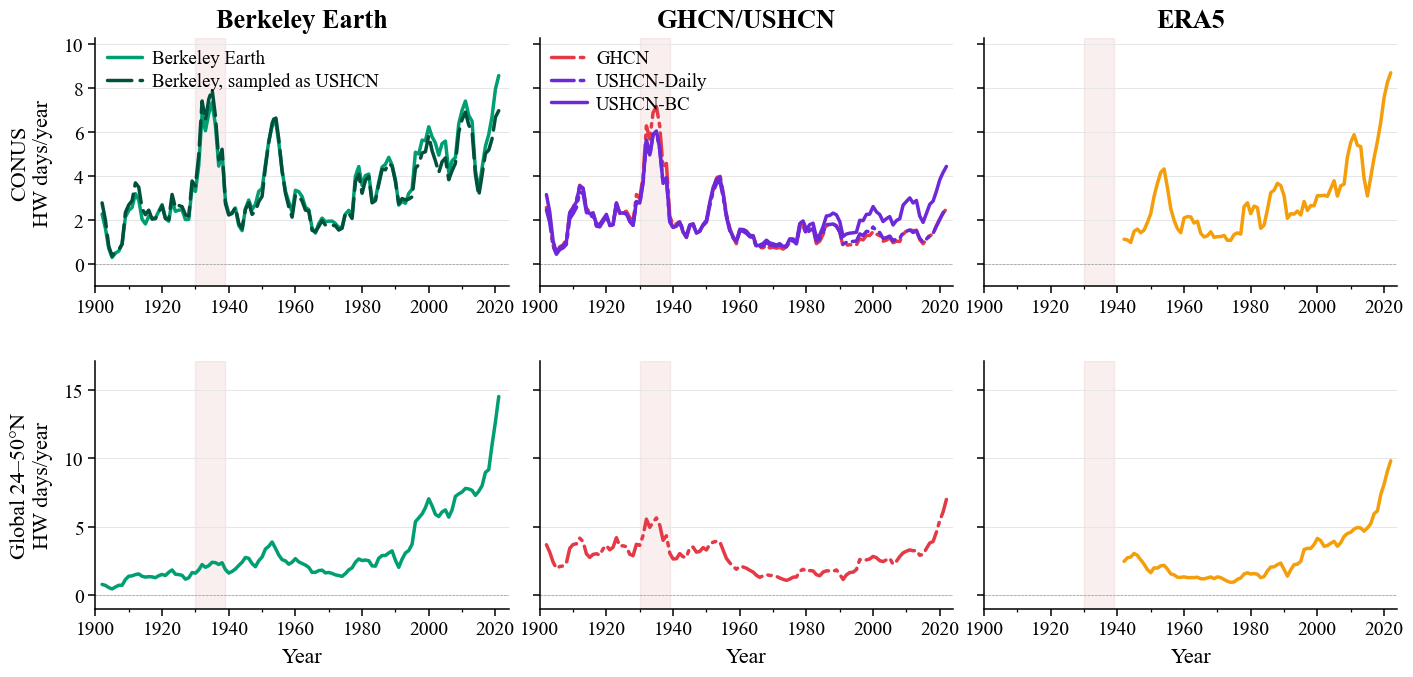

In [45]:
# ══ PLOT ═══════════════════════════════════════════════════════════════════
def _smooth(d, w=SMOOTH_W):
    """(6) year-indexed centred mean, full window required."""
    if not d: return {}
    s = pd.Series(d).sort_index()
    s = s.reindex(range(int(s.index.min()), int(s.index.max()) + 1))
    sm = s.rolling(w, center=True, min_periods=w).mean().dropna()
    return sm.to_dict()

PLOT_YRS = (1900, 2024)
ROW_LABELS = ["CONUS", "Global 24–50°N"]
ROW_DATA = [R_conus, R_global]
COL_TITLES = {"Berkeley": "Berkeley Earth", "GHCND": "GHCN/USHCN",
              "USHCN": "USHCN", "ERA5": "ERA5"}
EMPTY_NOTE = {("USHCN", 1): "CONUS-only network\n(no global coverage)"}
PRIMARY_LABEL = {("GHCND", 0): "GHCN", ("GHCND", 1): "GHCN",
                 ("USHCN", 0): "USHCN-BC", ("Berkeley", 0): "Berkeley Earth"}
# (A) uncorrected datasets are dot-dashed wherever they appear
PRIMARY_LS = {("GHCND", r): LS_UNCORR for r in GHCND_UNCORR_ROWS}

def _draw(ax, hw, color, ls="-", label=None, thin=True):
    """thin=False draws the smoothed curve only. Used for the Berkeley
    USHCN-sampling line: its annual values sit almost on top of the full-CONUS
    ones, so a second thin trace in the same colour only hides both curves."""
    if not hw: return False
    y = np.array(sorted(hw.keys())); v = np.array([hw[k] for k in y], float)
    ok = (y >= PLOT_YRS[0]) & (y <= PLOT_YRS[1])
    y, v = y[ok], v[ok]
    if y.size == 0: return False
    if thin and SHOW_ANNUAL_F6:                                  # (W2)(W5)
        ax.plot(y, v, lw=LW_ANNUAL, color=color, ls=ls, alpha=ALPHA_ANNUAL)
    sm = _smooth({a: b for a, b in zip(y, v) if not np.isnan(b)})
    if sm:
        sy = np.array(sorted(sm.keys()))
        ax.plot(sy, [sm[k] for k in sy], lw=LW_SMOOTH, color=color, ls=ls,
                label=label, solid_capstyle="round", dash_capstyle="round")
    return True

def build_figure(datasets, overlays, out_name, extra_for_scale=None):
    extra_for_scale = extra_for_scale or {}
    def _row_ymax(R, row):
        """(W5) scale to the annual traces (v G) or to the smoothed curves."""
        series = [R.get(dn, {}) for dn in datasets] + extra_for_scale.get(row, [])
        if YLIM_FROM == "smoothed":
            series = [_smooth(d) for d in series]
        vals = [v for d in series for v in d.values() if not np.isnan(v)]
        if not vals:
            return 20.
        return (np.percentile(vals, 99) * 1.20 if YLIM_FROM == "annual"
                else max(vals) * 1.18)
    ncol = len(datasets)
    fig, axes = plt.subplots(2, ncol, figsize=(PANEL_W * ncol, PANEL_H * 2.28),
                             gridspec_kw={"hspace": 0.30, "wspace": 0.075})
    for row, (row_label, R) in enumerate(zip(ROW_LABELS, ROW_DATA)):
        ymax = _row_ymax(R, row)
        for col in range(1, ncol):
            axes[row, col].sharey(axes[row, 0])
        for col, dn in enumerate(datasets):
            ax = axes[row, col]; hw = R.get(dn, {}); ovl = overlays.get((dn, row), [])
            drew = _draw(ax, hw, C[dn], PRIMARY_LS.get((dn, row), LS_ADJ),
                         label=(PRIMARY_LABEL.get((dn, row), COL_TITLES[dn])
                                if ovl else None))
            for _o in ovl:                      # (label, series, colour, ls[, thin])
                _l, _s, _c, _ls = _o[:4]
                drew |= _draw(ax, _s, _c, _ls, label=_l,
                              thin=(_o[4] if len(_o) > 4 else True))
            if not drew:
                ax.text(0.5, 0.5, EMPTY_NOTE.get((dn, row), "No data"),
                        transform=ax.transAxes, ha="center", va="center",
                        fontsize=FS_EMPTY, color="0.55", style="italic")
                ax.set_facecolor("0.97")
            elif ovl:
                ax.legend(loc="upper left", frameon=False, fontsize=FS_PANLEG,
                          handlelength=1.9, borderaxespad=0.2,
                          labelspacing=0.25, handletextpad=0.5)
            ax.set_xlim(*PLOT_YRS); ax.set_ylim(-1, ymax)
            ax.tick_params(axis="both", labelsize=FS_TICK, length=5, width=1.1)
            ax.xaxis.set_major_locator(mticker.MultipleLocator(20))      # (W4)
            ax.xaxis.set_minor_locator(mticker.MultipleLocator(10))
            ax.tick_params(axis="x", which="minor", length=2.5, width=0.9)
            ax.grid(True, axis="y", color="0.90", lw=0.7)                # (W4)
            ax.set_axisbelow(True)
            ax.axhline(0, color="0.6", lw=0.5, ls="--")
            ax.axvspan(1930, 1939, alpha=0.07, color="firebrick", zorder=0)
            if row == 0:
                ax.set_title(COL_TITLES[dn], color="black", fontweight="bold",
                             pad=8, fontsize=FS_COLTITLE)
            if col == 0:
                ax.set_ylabel(f"{row_label}\nHW days/year", fontsize=FS_YLABEL,
                              labelpad=8)
            else:
                plt.setp(ax.get_yticklabels(), visible=False)
            if row == 1:
                ax.set_xlabel("Year", fontsize=FS_XLABEL, labelpad=6)
    out = WORK / out_name
    fig.savefig(out, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show(); plt.close(fig)

_USHCN_LINES = [(lab, s, C["USHCN"], ls) for lab, s, ls in
                [("USHCN-Daily", R_ushcn_raw, LS_UNCORR),
                 ("USHCN-BC", R_ushcn_adj, LS_ADJ)] if s]
# (B) the dashed green line lives in the Berkeley panel of the CONUS row only
BE_AT_USHCN_THIN = False        # True to also draw its noisy annual trace
_BE_LINES = ([("Berkeley, sampled as USHCN", _be_u, C_SAMPLED, LS_SAMPLED,
               BE_AT_USHCN_THIN)] if _be_u else [])

_SCALE0 = [o[1] for o in _USHCN_LINES] + ([_be_u] if _be_u else [])

# figure 1: USHCN rides in the GHCN panel
_OVL_OVERLAY = {}
if _USHCN_LINES: _OVL_OVERLAY[("GHCND", 0)] = _USHCN_LINES
if _BE_LINES:    _OVL_OVERLAY[("Berkeley", 0)] = _BE_LINES

build_figure(["Berkeley", "GHCND", "ERA5"], _OVL_OVERLAY,
             "FigHW_conus_vs_global_ushcn_overlay_wide.png", {0: _SCALE0})
